In [1]:
# ---- Librerias ----
import os
import glob
import json
import joblib
import time
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

warnings.filterwarnings('ignore')

# ---- Configuracion global ----
SEED = 42
np.random.seed(SEED)

CLASSES = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']
SR = 16000
DURACION = 3.0
N_MUESTRAS = int(SR * DURACION)   # 48000

RUTA_CSV = '../Archivos-csv'
RUTA_MODELOS = '../Modelo-Entrenado'
os.makedirs(RUTA_CSV, exist_ok=True)
os.makedirs(RUTA_MODELOS, exist_ok=True)

# Todos los CSV compartidos viven en Archivos-csv/. El notebook nunca
# escribe CSV en su propia carpeta para no duplicar archivos.
RUTA_BASE     = os.path.join(RUTA_CSV, 'dataset_cremad_base.csv')
RUTA_FEATURES = os.path.join(RUTA_CSV, 'features_cremad.csv')
RUTA_PROBS    = os.path.join(RUTA_CSV, 'validation_probabilities.csv')
RUTA_PROBS_TEST = os.path.join(RUTA_CSV, 'test_probabilities.csv')
RUTA_PROSODIA = os.path.join(RUTA_CSV, 'features_prosodia_cremad.csv')
RUTA_SPLITS   = 'splits_actores_cremad.json'

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

print('Clases:', CLASSES)
print('CSV compartidos en:', os.path.abspath(RUTA_CSV))
print(f'Muestreo: {SR} Hz | Duracion fija: {DURACION}s ({N_MUESTRAS} muestras)')

Clases: ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']
CSV compartidos en: C:\Users\Bryan26\Desktop\Carpeta_machine\Macine_grupal\CREMA--D-Assembly-\Archivos-csv
Muestreo: 16000 Hz | Duracion fija: 3.0s (48000 muestras)


### **EDA of the audio files** 

**Names of the audio files:** Author ID, Phrase, Emotion, Intensity of emotion.

**Phrases:** 
* IEO: It's eleven o'clock
* TIE: That is exactly what happened
* IOM: I'm on my way to the meeting
* IWW: I wonder what this is about
* TAI: The airplane is almost full
* MTI: Maybe tomorrow it will be cold
* IWL: I would like a new alarm clock
* ITH: I think I have a doctor's appointment
* DFA: Don't forget a jacket
* ITS: I think I've seen this before
* TSI: The surface is slick
* WSI: We'll stop in a couple of minutes

**Intensity of emotion:**
* LO: Low
* MD: Medium
* HI: High
* XX: Unspecified 

In [2]:
#Audio dataset root directory
DATASET_ROOT = "../AudioWAV"

In [3]:
import IPython.display as ipd
ipd.Audio(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"))

## Extraction Data
1. Extraction of the Minimum, Maximum, Averague  duration.
2. Extraction of the number by emotions.
3. Class distribution
4. Visualization of two spectrograms 

Total de audios: 7442
Frecuencias de muestreo: {16000}
Canales: {1}

Minima : 1.27 s
Maxima : 5.00 s
Media  : 2.54 s
Mediana: 2.50 s
  P75: 2.84 s
  P90: 3.17 s
  P95: 3.47 s
  P99: 4.04 s

Audios que superan 3.0s (se truncan): 1252 (16.82%)
Audios mas cortos (se repiten): 6190 (83.18%)


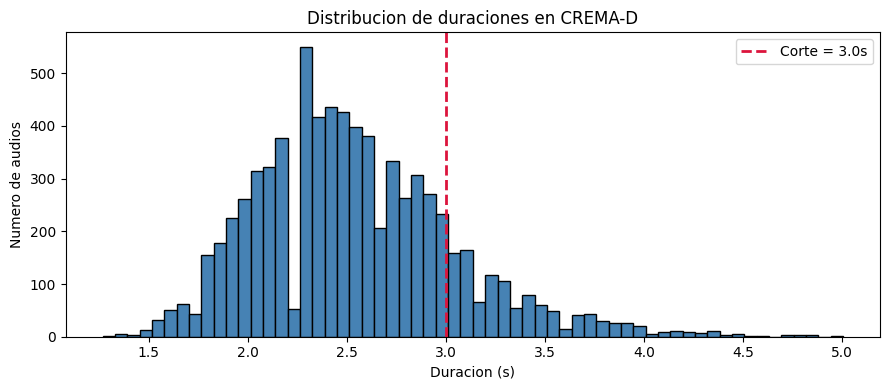

In [4]:
audio_files = sorted(glob.glob(os.path.join(DATASET_ROOT, "*.wav")))

info = [sf.info(f) for f in audio_files]
durations = np.array([i.duration for i in info])

print(f"Total de audios: {len(durations)}")
print(f"Frecuencias de muestreo: {set(i.samplerate for i in info)}")
print(f"Canales: {set(i.channels for i in info)}")
print(f"\nMinima : {durations.min():.2f} s")
print(f"Maxima : {durations.max():.2f} s")
print(f"Media  : {durations.mean():.2f} s")
print(f"Mediana: {np.median(durations):.2f} s")
for q in [75, 90, 95, 99]:
    print(f"  P{q}: {np.percentile(durations, q):.2f} s")

n_trunc = (durations > DURACION).sum()
print(f"\nAudios que superan {DURACION}s (se truncan): {n_trunc} ({100*n_trunc/len(durations):.2f}%)")
print(f"Audios mas cortos (se repiten): {len(durations)-n_trunc} ({100*(1-n_trunc/len(durations)):.2f}%)")

plt.figure(figsize=(9, 4))
plt.hist(durations, bins=60, color='steelblue', edgecolor='black')
plt.axvline(DURACION, color='crimson', ls='--', lw=2, label=f'Corte = {DURACION}s')
plt.xlabel('Duracion (s)'); plt.ylabel('Numero de audios')
plt.title('Distribucion de duraciones en CREMA-D'); plt.legend()
plt.tight_layout(); plt.show()

CSV base guardado en '../Archivos-csv\dataset_cremad_base.csv' con 7442 filas.

             sample_id id_actor true_label
0  1001_DFA_ANG_XX.wav     1001        ANG
1  1001_DFA_DIS_XX.wav     1001        DIS
2  1001_DFA_FEA_XX.wav     1001        FEA
3  1001_DFA_HAP_XX.wav     1001        HAP
4  1001_DFA_NEU_XX.wav     1001        NEU 

{'ANG': 1271, 'DIS': 1271, 'FEA': 1271, 'HAP': 1271, 'NEU': 1087, 'SAD': 1271}


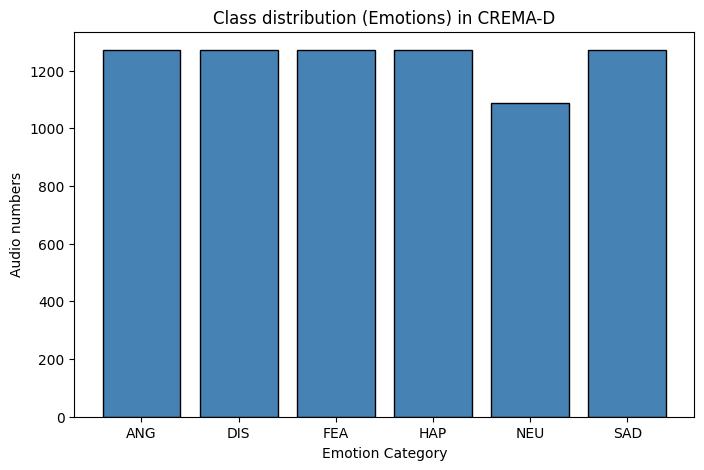

In [5]:
# ---- Metadatos base + distribucion de clases ----
# El CSV base se escribe en Archivos-csv/ (no en Notebook/) para que exista
# una sola copia compartida por el grupo.

count_emotions = {c: 0 for c in CLASSES}
datos_audios = []

for audio_file in audio_files:
    filename = os.path.basename(audio_file)
    partes = filename.split('_')
    if len(partes) >= 3:
        id_actor, emocion = partes[0], partes[2]
        count_emotions[emocion] += 1
        datos_audios.append({
            'sample_id': filename,
            'id_actor': id_actor,
            'true_label': emocion,
        })

df_metadatos = (pd.DataFrame(datos_audios)
                  .sort_values('sample_id')
                  .reset_index(drop=True))
df_metadatos.to_csv(RUTA_BASE, index=False)
print(f"CSV base guardado en '{RUTA_BASE}' con {len(df_metadatos)} filas.\n")
print(df_metadatos.head(), '\n')

print(count_emotions)

# ---- Distribucion de clases ----
plt.figure(figsize=(8, 5))
plt.bar(list(count_emotions.keys()), list(count_emotions.values()),
        color='steelblue', edgecolor='black')
plt.title('Class distribution (Emotions) in CREMA-D')
plt.xlabel('Emotion Category')
plt.ylabel('Audio numbers')
plt.show()

_(Se elimino la celda duplicada que volvia a contar las emociones y a dibujar la misma grafica: ya lo hace la celda anterior.)_

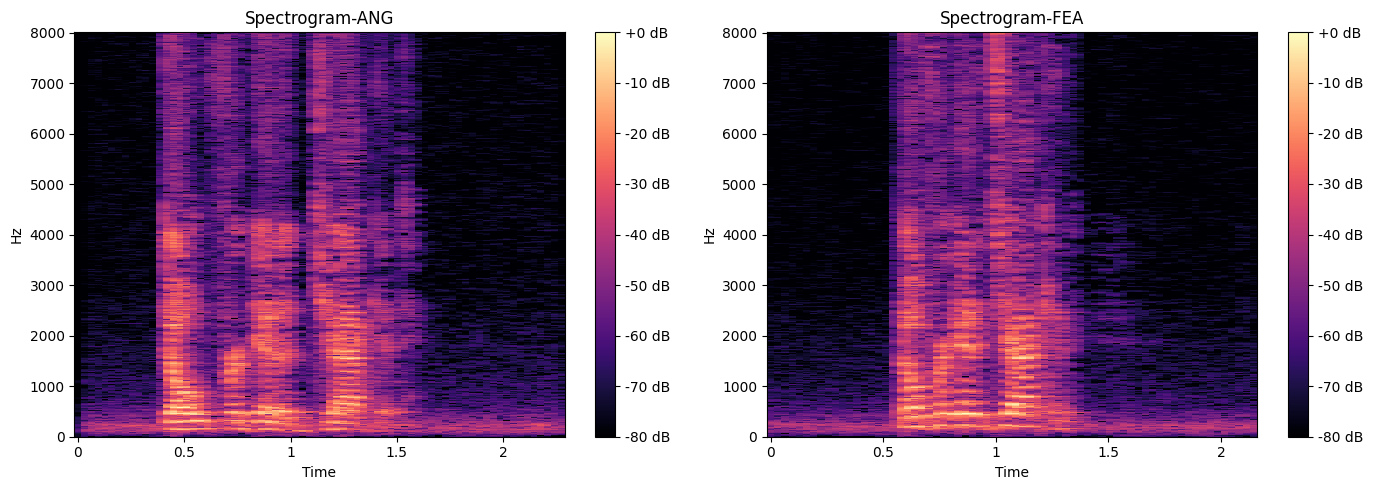

In [6]:
#Visualization of two spectrograms 
wav1, sr = librosa.load(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"), sr= None)
wav2, sr = librosa.load(os.path.join(DATASET_ROOT, "1001_DFA_FEA_XX.wav"), sr= None)


spec1 = librosa.amplitude_to_db(np.abs(librosa.stft(wav1)), ref=np.max)
spec2 = librosa.amplitude_to_db(np.abs(librosa.stft(wav2)), ref=np.max)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
img1 =librosa.display.specshow(spec1, y_axis='linear', x_axis= 'time', sr=sr, ax= ax[0])
ax[0].set_title('Spectrogram-ANG')
img2 =librosa.display.specshow(spec2, y_axis='linear', x_axis= 'time', sr=sr, ax= ax[1])
ax[1].set_title('Spectrogram-FEA')

fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

### 

### **Promedio del Audio y ajuste**

In [7]:
# Processing audio files

def pad_or_truncate_audio(file_path, n=N_MUESTRAS, sr=SR):
    """
    Carga canonica compartida por los cinco modelos.
    - Trunca a 3 s los audios largos (16.8% del dataset)
    - Repite los cortos hasta completar 3 s (loop-padding)
    Devuelve siempre exactamente 48000 muestras.
    """
    try:
        wav, _ = librosa.load(file_path, sr=sr)
        if len(wav) >= n:
            return wav[:n], sr
        repeticiones = int(np.ceil(n / len(wav)))
        return np.tile(wav, repeticiones)[:n], sr
    except Exception as e:
        print(f"Error processing file {os.path.basename(file_path)}: {e}")
        return None, None

In [8]:
#test
wav_fixed, sr = pad_or_truncate_audio(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"))


print(f"Original duration: {librosa.get_duration(path=os.path.join(DATASET_ROOT, '1001_DFA_ANG_XX.wav')):.2f} seconds")
print(f"Fixed duration: {librosa.get_duration(y=wav_fixed, sr=sr):.2f} seconds")  # Assuming default sampling rate of 22050 Hz

Original duration: 2.28 seconds
Fixed duration: 3.00 seconds


### Data Leakage
Separados 70-15-15 pero por la cantidad de actores del dataset

In [9]:
def extraer_caracteristicas_acusticas(WAV_signal, tasa_muestreo=SR):
    mfcc   = librosa.feature.mfcc(y=WAV_signal, sr=tasa_muestreo, n_mfcc=20)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    c = {}
    for nombre, M in [('mfcc', mfcc), ('delta', delta), ('delta2', delta2)]:
        medias, desvs = M.mean(axis=1), M.std(axis=1)
        for i in range(M.shape[0]):
            c[f'{nombre}_{i+1}_mean'] = medias[i]
            c[f'{nombre}_{i+1}_std']  = desvs[i]

    c['tasa_cruces_cero']      = float(np.mean(librosa.feature.zero_crossing_rate(y=WAV_signal)))
    c['centroide_espectral']   = float(np.mean(librosa.feature.spectral_centroid(y=WAV_signal, sr=tasa_muestreo)))
    c['energia_rms']           = float(np.mean(librosa.feature.rms(y=WAV_signal)))
    c['rolloff_espectral']     = float(np.mean(librosa.feature.spectral_rolloff(y=WAV_signal, sr=tasa_muestreo, roll_percent=0.85)))
    c['ancho_banda_espectral'] = float(np.mean(librosa.feature.spectral_bandwidth(y=WAV_signal, sr=tasa_muestreo)))
    c['contraste_espectral']   = float(np.mean(librosa.feature.spectral_contrast(y=WAV_signal, sr=tasa_muestreo)))
    c['plenitud_espectral']    = float(np.mean(librosa.feature.spectral_flatness(y=WAV_signal)))
    return c

In [10]:
def procesar_dataset_y_crear_dataframe(ruta_dataset):
    """
    Itera sobre los audios, ajusta su duracion y extrae caracteristicas.
    Ordena por sample_id para que todos los integrantes obtengan
    las filas en el mismo orden, sin depender de glob.
    """
    rutas_archivos_audio = glob.glob(os.path.join(ruta_dataset, "*.wav"))
    lista_datos_completos = []
    total_archivos = len(rutas_archivos_audio)

    print(f"Iniciando extraccion de caracteristicas de {total_archivos} archivos...")

    for contador, ruta_archivo in enumerate(rutas_archivos_audio, start=1):
        nombre_archivo = os.path.basename(ruta_archivo)
        partes_nombre = nombre_archivo.split('_')

        if len(partes_nombre) >= 3:
            id_actor = partes_nombre[0]
            etiqueta_emocion = partes_nombre[2]

            audio_ajustado, tasa_muestreo = pad_or_truncate_audio(ruta_archivo)

            if audio_ajustado is not None:
                datos_fila = extraer_caracteristicas_acusticas(audio_ajustado, tasa_muestreo)
                datos_fila['sample_id'] = nombre_archivo
                datos_fila['id_actor']  = id_actor
                datos_fila['emocion']   = etiqueta_emocion
                lista_datos_completos.append(datos_fila)

        if contador % 500 == 0:
            print(f"Procesados {contador} de {total_archivos} audios...")

    print("Extraccion completada.")
    return pd.DataFrame(lista_datos_completos).sort_values('sample_id').reset_index(drop=True)

In [11]:
# ---- Extraccion de caracteristicas (con cache) ----
# Si features_cremad.csv ya existe se reutiliza: reprocesar los 7442 audios
# tarda varios minutos y el resultado es identico (la extraccion es determinista).
# Para forzar el recalculo pon RECALCULAR_FEATURES = True.

RECALCULAR_FEATURES = False

if (not RECALCULAR_FEATURES) and os.path.exists(RUTA_FEATURES):
    df_caracteristicas = pd.read_csv(RUTA_FEATURES)
    df_caracteristicas['id_actor'] = df_caracteristicas['id_actor'].astype(str)
    print(f'Caracteristicas cargadas desde {RUTA_FEATURES}')
else:
    df_caracteristicas = procesar_dataset_y_crear_dataframe(DATASET_ROOT)
    df_caracteristicas.to_csv(RUTA_FEATURES, index=False)
    print(f'Caracteristicas guardadas en {RUTA_FEATURES}')

print(df_caracteristicas.shape)          # esperado: (7442, 130)
print(df_caracteristicas['sample_id'].is_unique)
df_caracteristicas.head()

Caracteristicas cargadas desde ../Archivos-csv\features_cremad.csv
(7442, 130)
True


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,mfcc_6_mean,mfcc_6_std,mfcc_7_mean,mfcc_7_std,mfcc_8_mean,mfcc_8_std,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,...,delta2_13_std,delta2_14_mean,delta2_14_std,delta2_15_mean,delta2_15_std,delta2_16_mean,delta2_16_std,delta2_17_mean,delta2_17_std,delta2_18_mean,delta2_18_std,delta2_19_mean,delta2_19_std,delta2_20_mean,delta2_20_std,tasa_cruces_cero,centroide_espectral,energia_rms,rolloff_espectral,ancho_banda_espectral,contraste_espectral,plenitud_espectral,sample_id,id_actor,emocion
0,-306.94455,161.495420,94.363420,27.566635,10.055119,33.235300,22.259483,18.526869,5.779584,20.003164,-5.614751,17.808657,-9.813098,14.673255,-10.095236,15.400408,-5.265654,6.991499,-13.033746,7.543640,0.514165,7.422677,-10.143759,8.294315,-5.955340,...,0.860958,-0.026949,1.053571,0.015169,0.633071,-0.042829,0.903629,0.042528,0.675324,0.055185,0.634657,0.002610,0.763219,-0.027480,0.691229,0.097319,1561.377525,0.044587,3208.444149,1804.235155,17.695071,0.024719,1001_DFA_ANG_XX.wav,1001,ANG
1,-355.88120,121.131454,97.562614,23.529482,12.001207,28.857822,30.913574,13.492492,15.575253,12.887399,-4.891905,17.574656,-5.722921,11.151229,-5.124552,11.305930,-5.438893,8.334834,-9.735347,5.512251,-2.169454,7.912293,-7.077807,6.440149,-6.628007,...,0.709695,0.032078,0.671813,0.006466,0.510917,0.006042,0.658202,-0.015539,0.612727,0.034427,0.390973,0.082750,0.714534,-0.036726,0.679481,0.085475,1488.787940,0.015736,3039.893617,1794.424087,16.549577,0.022884,1001_DFA_DIS_XX.wav,1001,DIS
2,-324.73798,166.712570,97.263180,20.042433,9.348844,31.935633,21.147984,17.946167,10.948439,15.944604,-5.452253,17.506330,-7.649064,13.833654,-6.031546,11.028845,-5.832608,6.488420,-13.302959,8.325360,-3.463395,6.696230,-8.775144,5.304351,-6.832579,...,0.749406,0.094802,1.091607,0.011308,0.427846,0.058775,0.626696,0.051735,0.782318,-0.052915,0.618021,-0.010305,0.659100,0.037773,0.595116,0.079257,1451.841364,0.045135,2980.634973,1802.213722,17.190227,0.017177,1001_DFA_FEA_XX.wav,1001,FEA
3,-269.40130,156.146710,89.331570,23.537611,-0.507037,29.448124,26.549429,18.175160,7.733314,18.879517,-14.234652,18.799410,-12.094867,13.919965,-10.051626,13.717805,-7.544462,9.228237,-18.195396,9.030563,0.163942,7.982137,-9.209809,7.036780,-9.929687,...,0.913364,0.093530,1.070347,0.045299,1.024252,-0.005430,0.728189,-0.102028,0.684821,-0.077821,0.832878,0.004063,0.707974,0.058978,0.724442,0.093662,1628.602442,0.051515,3299.035904,1807.360061,17.880022,0.020990,1001_DFA_HAP_XX.wav,1001,HAP
4,-321.42600,109.912610,98.977340,25.306738,7.985224,24.491617,29.238186,15.077043,10.251309,17.905144,-3.592251,14.818153,-9.673445,16.817440,-11.447524,12.636653,-6.652886,9.643683,-13.258989,9.191231,1.791616,10.258380,-10.547569,8.565592,-2.878854,...,1.206173,-0.053005,1.004802,0.006272,0.628292,-0.064992,0.788980,-0.007915,0.652712,0.080547,0.809937,-0.055802,0.439023,0.042974,0.683287,0.083595,1527.712642,0.024221,3161.402926,1779.618201,17.235060,0.021686,1001_DFA_NEU_XX.wav,1001,NEU


### Representacion 2: prosodia y dinamica temporal (waveform)

Las caracteristicas de `features_cremad.csv` son todas **espectrales o cepstrales**:
describen *como se reparte la energia en frecuencia*. Un ensemble construido solo
sobre ellas tiene modelos que se equivocan en los mismos audios.

Esta segunda representacion se calcula **en el dominio del tiempo**, directamente
sobre la forma de onda, y no pasa por el espectro en ningun punto:

| Grupo | Que mide |
|---|---|
| F0 (pitch por YIN) | entonacion: media, rango, pendiente, jitter, ratio sonoro |
| Contorno de energia RMS | intensidad y su dinamica, shimmer |
| Cruces por cero | proporcion de sonidos sordos |
| Envolvente | tiempo hasta el pico, ataque y caida |
| Ritmo | ratio de silencio, numero de nucleos silabicos e intervalos |
| Amplitud | pico, factor de cresta, entropia de energia, periodicidad |

Son 40 caracteristicas. Es la rama **Waveform** del esquema del enunciado y la
usa el Modelo 1.

**Por que no meter las 48000 muestras crudas a un SVM:** 48000 dimensiones con
5152 muestras de entrenamiento sobreajusta sin remedio, y un kernel RBF sobre la
senal cruda es practicamente ruido, porque desplazar el audio unos milisegundos
cambia el vector entero sin cambiar la emocion.

In [12]:
# ---- Caracteristicas prosodicas y temporales (dominio del tiempo) ----
F0_MIN, F0_MAX = 60, 350
FRAME_PROS, HOP_PROS = 2048, 512


def _stats_contorno(x, prefijo):
    """Estadisticos de un contorno temporal, incluida su pendiente."""
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x))
    pend = np.polyfit(t, x, 1)[0] if len(x) > 1 and np.ptp(x) > 0 else 0.0
    return {f'{prefijo}_media': float(np.mean(x)), f'{prefijo}_desv': float(np.std(x)),
            f'{prefijo}_min': float(np.min(x)),   f'{prefijo}_max': float(np.max(x)),
            f'{prefijo}_rango': float(np.ptp(x)),
            f'{prefijo}_p25': float(np.percentile(x, 25)),
            f'{prefijo}_p75': float(np.percentile(x, 75)),
            f'{prefijo}_pendiente': float(pend)}


def extraer_prosodia(wav, sr=SR):
    c = {}

    # 1. Pitch (F0) por YIN -> entonacion
    f0 = librosa.yin(wav, fmin=F0_MIN, fmax=F0_MAX, sr=sr,
                     frame_length=FRAME_PROS, hop_length=HOP_PROS)
    # YIN da un valor en todos los frames; los que pegan en los limites del
    # rango son casi siempre frames sordos o silencio.
    voz = (f0 > F0_MIN * 1.05) & (f0 < F0_MAX * 0.95)
    c['f0_ratio_sonoro'] = float(voz.mean())
    f0_voz = f0[voz] if voz.sum() >= 2 else np.array([0.0, 0.0])
    c.update(_stats_contorno(f0_voz, 'f0'))
    c['f0_jitter'] = float(np.mean(np.abs(np.diff(f0_voz))) / (np.mean(f0_voz) + 1e-9)) \
        if len(f0_voz) > 1 else 0.0

    # 2. Contorno de energia RMS -> intensidad y dinamica
    rms = librosa.feature.rms(y=wav, frame_length=FRAME_PROS, hop_length=HOP_PROS)[0]
    c.update(_stats_contorno(rms, 'rms'))
    c['rms_shimmer'] = float(np.mean(np.abs(np.diff(rms))) / (np.mean(rms) + 1e-9))

    # 3. Cruces por cero -> proporcion de sonidos sordos
    zcr = librosa.feature.zero_crossing_rate(wav, frame_length=FRAME_PROS,
                                             hop_length=HOP_PROS)[0]
    c.update(_stats_contorno(zcr, 'zcr'))

    # 4. Envolvente -> ataque y caida
    pico = int(np.argmax(rms))
    c['env_tiempo_pico'] = float(pico / max(1, len(rms) - 1))
    c['env_ataque'] = float(rms[pico] / (pico + 1))
    c['env_caida'] = float(rms[pico] / (len(rms) - pico))

    # 5. Ritmo -> silencios y nucleos silabicos
    umbral = 0.3 * rms.max() if rms.max() > 0 else 0.0
    activo = rms > umbral
    c['ritmo_ratio_silencio'] = float(1.0 - activo.mean())
    inicios = np.flatnonzero((~activo[:-1]) & activo[1:])
    c['ritmo_n_nucleos'] = float(len(inicios))
    c['ritmo_intervalo_medio'] = float(np.mean(np.diff(inicios))) if len(inicios) > 1 else 0.0
    c['ritmo_intervalo_desv'] = float(np.std(np.diff(inicios))) if len(inicios) > 1 else 0.0

    # 6. Amplitud global y factor de cresta
    rms_g = float(np.sqrt(np.mean(wav ** 2)))
    c['amp_pico'] = float(np.max(np.abs(wav)))
    c['amp_media_abs'] = float(np.mean(np.abs(wav)))
    c['amp_rms'] = rms_g
    c['amp_cresta'] = float(np.max(np.abs(wav)) / (rms_g + 1e-9))

    # 7. Entropia de la energia -> como se reparte en el tiempo
    p = rms / (rms.sum() + 1e-9)
    c['energia_entropia'] = float(-np.sum(p * np.log(p + 1e-12)))

    # 8. Periodicidad por autocorrelacion
    ac = librosa.autocorrelate(wav, max_size=sr // F0_MIN)
    ac = ac / (ac[0] + 1e-9)
    c['autocorr_pico'] = float(np.max(ac[sr // F0_MAX:])) if len(ac) > sr // F0_MAX else 0.0
    return c


RECALCULAR_PROSODIA = False

if (not RECALCULAR_PROSODIA) and os.path.exists(RUTA_PROSODIA):
    df_prosodia = pd.read_csv(RUTA_PROSODIA)
    df_prosodia['id_actor'] = df_prosodia['id_actor'].astype(str)
    print(f'Prosodia cargada de cache: {RUTA_PROSODIA}')
else:
    t0, filas = time.time(), []
    for i, sid in enumerate(df_caracteristicas['sample_id'], 1):
        wav, _ = pad_or_truncate_audio(os.path.join(DATASET_ROOT, sid))
        filas.append(extraer_prosodia(wav))
        if i % 1500 == 0:
            print(f'  {i}/{len(df_caracteristicas)}  ({time.time()-t0:.0f}s)')
    df_prosodia = pd.DataFrame(filas)
    for col in ['sample_id', 'id_actor', 'emocion']:
        df_prosodia[col] = df_caracteristicas[col].values
    df_prosodia.to_csv(RUTA_PROSODIA, index=False)
    print(f'Prosodia calculada en {time.time()-t0:.0f}s -> {RUTA_PROSODIA}')

# Debe ir fila a fila con df_caracteristicas para que idx_train/val/test sirvan igual
assert list(df_prosodia['sample_id']) == list(df_caracteristicas['sample_id'])
print(f'{df_prosodia.shape[1]-3} caracteristicas prosodicas | {df_prosodia.shape[0]} audios')
df_prosodia.head()

Prosodia cargada de cache: ../Archivos-csv\features_prosodia_cremad.csv
40 caracteristicas prosodicas | 7442 audios


,f0_ratio_sonoro,f0_media,f0_desv,f0_min,f0_max,f0_rango,f0_p25,f0_p75,f0_pendiente,f0_jitter,rms_media,rms_desv,rms_min,rms_max,rms_rango,rms_p25,rms_p75,rms_pendiente,rms_shimmer,zcr_media,zcr_desv,zcr_min,zcr_max,zcr_rango,zcr_p25,zcr_p75,zcr_pendiente,env_tiempo_pico,env_ataque,env_caida,ritmo_ratio_silencio,ritmo_n_nucleos,ritmo_intervalo_medio,ritmo_intervalo_desv,amp_pico,amp_media_abs,amp_rms,amp_cresta,energia_entropia,autocorr_pico,sample_id,id_actor,emocion
0,1.000000,150.397138,50.318447,66.081454,257.576363,191.494909,119.778421,159.733143,-0.114861,0.192103,0.044587,0.052230,0.002010,0.176748,0.174738,0.004338,0.075768,-0.000160,0.250159,0.097319,0.058247,0.031738,0.288086,0.256348,0.047974,0.138062,-0.000246,0.161290,0.011047,0.002237,0.648936,4.0,23.666667,15.923428,0.631042,0.031341,0.068873,9.162454,3.897685,0.304899,1001_DFA_ANG_XX.wav,1001,ANG
1,1.000000,167.366651,67.983370,68.667361,268.502243,199.834882,108.460246,228.726173,-0.056116,0.242543,0.015736,0.016585,0.003022,0.062648,0.059626,0.004718,0.021789,-0.000068,0.186936,0.085475,0.059901,0.019531,0.299316,0.279785,0.043457,0.122437,-0.000358,0.204301,0.003132,0.000835,0.702128,3.0,36.000000,17.000000,0.284088,0.011868,0.023528,12.074463,4.083931,0.211484,1001_DFA_DIS_XX.wav,1001,DIS
2,1.000000,175.405062,55.506091,67.268301,240.173893,172.905592,126.739773,220.978209,-0.113398,0.251787,0.045135,0.059992,0.002977,0.199814,0.196837,0.004364,0.098815,-0.000117,0.212361,0.079257,0.051324,0.016602,0.253906,0.237305,0.041504,0.106323,-0.000193,0.365591,0.005709,0.003330,0.691489,2.0,67.000000,0.000000,0.693176,0.032775,0.075593,9.169798,3.732174,0.327948,1001_DFA_FEA_XX.wav,1001,FEA
3,0.978723,175.130033,47.481297,68.614266,244.198426,175.584160,157.121156,209.445770,0.196073,0.141032,0.051515,0.049768,0.003821,0.165824,0.162003,0.004891,0.093717,0.000206,0.246943,0.093662,0.052345,0.024902,0.250977,0.226074,0.050049,0.126099,0.000422,0.763441,0.002303,0.007210,0.563830,4.0,22.333333,18.856181,0.768768,0.036111,0.071802,10.706786,4.046928,0.357697,1001_DFA_HAP_XX.wav,1001,HAP
4,0.925532,146.791018,54.981781,71.548358,252.438958,180.890601,109.814690,211.888382,-0.157384,0.195945,0.024221,0.024826,0.004037,0.087737,0.083700,0.005147,0.030166,0.000109,0.231741,0.083595,0.038280,0.015625,0.216797,0.201172,0.050537,0.103027,-0.000061,0.268817,0.003374,0.001272,0.712766,4.0,25.000000,19.798990,0.315002,0.017429,0.034800,9.051717,4.080753,0.548062,1001_DFA_NEU_XX.wav,1001,NEU


Train: 5152 audios (69.2%) | 63 actores
Val  : 1142 audios (15.3%) | 14 actores
Test : 1148 audios (15.4%) | 14 actores

Verificacion speaker-disjoint:
  Train ∩ Val : set()
  Train ∩ Test: set()
  Val   ∩ Test: set()
>>> Sin fuga de hablantes.

Distribucion de emociones por particion:
         Train  Validation  Test
emocion                         
ANG        880         195   196
DIS        880         195   196
FEA        880         195   196
HAP        880         195   196
NEU        752         167   168
SAD        880         195   196

Proporciones:
         Train  Validation   Test
emocion                          
ANG      0.171       0.171  0.171
DIS      0.171       0.171  0.171
FEA      0.171       0.171  0.171
HAP      0.171       0.171  0.171
NEU      0.146       0.146  0.146
SAD      0.171       0.171  0.171


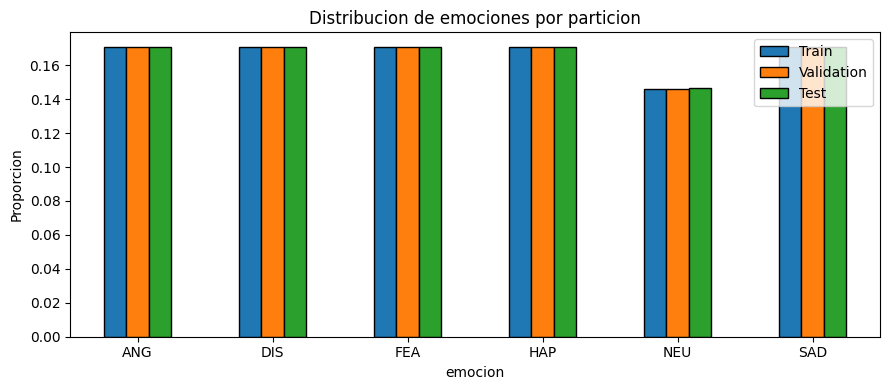

In [13]:
# ---- Split oficial del grupo: se CARGA, no se recalcula ----
with open(RUTA_SPLITS, encoding='utf-8') as f:
    splits = json.load(f)

# Los ids del JSON son cadenas; se normalizan por si alguien los guardo como int.
splits = {k: [str(a) for a in v] for k, v in splits.items()}
X = df_caracteristicas.drop(columns=['sample_id', 'id_actor', 'emocion'])
y = df_caracteristicas['emocion']
actores = df_caracteristicas['id_actor'].astype(str)

idx_train = np.where(actores.isin(splits['train']))[0]
idx_val   = np.where(actores.isin(splits['val']))[0]
idx_test  = np.where(actores.isin(splits['test']))[0]

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
y_train, y_val, y_test = y.iloc[idx_train], y.iloc[idx_val], y.iloc[idx_test]

set_train = set(actores.iloc[idx_train])
set_val   = set(actores.iloc[idx_val])
set_test  = set(actores.iloc[idx_test])

print(f"Train: {len(idx_train)} audios ({100*len(idx_train)/len(X):.1f}%) | {len(set_train)} actores")
print(f"Val  : {len(idx_val)} audios ({100*len(idx_val)/len(X):.1f}%) | {len(set_val)} actores")
print(f"Test : {len(idx_test)} audios ({100*len(idx_test)/len(X):.1f}%) | {len(set_test)} actores")

print("\nVerificacion speaker-disjoint:")
print(f"  Train ∩ Val : {set_train & set_val}")
print(f"  Train ∩ Test: {set_train & set_test}")
print(f"  Val   ∩ Test: {set_val & set_test}")

assert len(idx_train) + len(idx_val) + len(idx_test) == len(X), "Hay actores fuera del split"
assert not (set_train & set_val) and not (set_train & set_test) and not (set_val & set_test)
print(">>> Sin fuga de hablantes.")

# ---- Distribucion de emociones por particion ----
dist = pd.concat([
    y.iloc[idx_train].value_counts().rename('Train'),
    y.iloc[idx_val].value_counts().rename('Validation'),
    y.iloc[idx_test].value_counts().rename('Test'),
], axis=1).reindex(CLASSES)

print("\nDistribucion de emociones por particion:")
print(dist)
print("\nProporciones:")
print((dist / dist.sum()).round(3))

(dist / dist.sum()).plot(kind='bar', figsize=(9, 4), edgecolor='black')
plt.title('Distribucion de emociones por particion'); plt.ylabel('Proporcion')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [14]:
# import json

# # 1. Convertir los sets a listas (JSON no soporta formato 'set')
# distribucion_actores = {
#     "train": list(set_train),
#     "val": list(set_val),
#     "test": list(set_test)
# }

# # 2. Guardar en un archivo JSON
# ruta_archivo = "splits_actores_cremad.json"
# with open(ruta_archivo, "w") as f:
#     json.dump(distribucion_actores, f, indent=4)

# print(f"Distribución exportada exitosamente en '{ruta_archivo}'")

## Modelos 

#### Intrucciones:
* Explicar claramente cómo representa el audio y pq se eligieorn el modelo y que caracteristicas se deben extraer.
* Entrenar el modelo con el set separado (Ejecutar la siguiente celda para obtener estas divisiones del dataset)
* Cuando el modelo este entrenado Exportar como archivo pkl y guardarlo en Modelo-Entrenado.
* Obtener los resultados de las metricas y guardar en un archivo "modelo.text" (Para luego hacer la matriz de confunsion)
* **En caso de que el modelo entre dentro de estos conceptos hacer con el set de validation:**
**Modelos de Machine Learning Tradicional (SVM, Regresión Logística, Random Forest):** Aquí generalmente no hay "épocas" de entrenamiento iterativo, por lo que no usarás early stopping ni guardarás "checkpoints". El conjunto de Validation te servirá únicamente para ajustar hiperparámetros (como evaluar qué valor de C es mejor para el SVM, o cuántos estimadores necesita el Random Forest).
**Deep Learning (CNN, LSTM, Modelos preentrenados como HuBERT):** Estos modelos sí aprenden de forma iterativa a lo largo de varias épocas. Aquí sí es casi obligatorio usar Validation para monitorear el loss, aplicar early stopping para no sobreajustar, y guardar el mejor checkpoint de los pesos de la red.
* Sacar las probabilidades y AGREGAR en Archivos-csv/Probabilidades.csv las probabilidades que extraen de su modelo (Codigo mas abajo)

In [15]:
# Division en Train/Val/Test a partir del JSON oficial.
# Reutiliza el dict `splits` cargado en la celda anterior (no lo vuelve a leer)
# y produce exactamente las mismas particiones.

def aplicar_particion_json(df, splits=splits):
    ids = df['id_actor'].astype(str)
    cols_meta = ['sample_id', 'id_actor', 'emocion', 'true_label']

    def parte(nombre):
        sub = df[ids.isin(splits[nombre])]
        return sub.drop(columns=cols_meta, errors='ignore'), sub['emocion']

    X_tr, y_tr = parte('train')
    X_va, y_va = parte('val')
    X_te, y_te = parte('test')
    return X_tr, y_tr, X_va, y_va, X_te, y_te


X_train, y_train, X_val, y_val, X_test, y_test = aplicar_particion_json(df_caracteristicas)

# Deben coincidir con los indices de la celda anterior; si no, ids_val/ids_test
# quedarian desalineados con las probabilidades sin que nadie lo note.
assert list(X_train.index) == list(idx_train)
assert list(X_val.index) == list(idx_val)
assert list(X_test.index) == list(idx_test)

print(f"Audios Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Audios Train: 5152 | Val: 1142 | Test: 1148


In [16]:
NOMBRES = {'ANG': 'anger', 'DIS': 'disgust', 'FEA': 'fear',
           'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad'}


def agregar_probabilidades_modelo(probabilidades, clases_modelo, num_modelo,
                                  ids_val, y_val_true, ruta_csv=RUTA_PROBS):
    """
    Anade las probabilidades de un modelo al CSV compartido, alineando por
    sample_id (asi el orden de filas de cada integrante no importa).

    Si el archivo existente no es un CSV de probabilidades valido -por ejemplo
    si alguien copio encima el dataset base- se reconstruye desde cero en vez
    de abortar con un assert.
    """
    idx = [list(clases_modelo).index(c) for c in CLASSES]
    P = np.asarray(probabilidades)[:, idx]

    assert P.shape == (len(ids_val), 6), f'Shape inesperado: {P.shape}'
    assert np.allclose(P.sum(axis=1), 1.0), 'Las probabilidades no suman 1'

    nuevo = pd.DataFrame({'sample_id': ids_val, 'true_label': y_val_true})
    for j, c in enumerate(CLASSES):
        nuevo[f'prob_model_{num_modelo}_{NOMBRES[c]}'] = P[:, j]

    base = None
    if os.path.exists(ruta_csv):
        base = pd.read_csv(ruta_csv)
        cols_prob = [c for c in base.columns if c.startswith('prob_model_')]
        mismos_ids = set(base.get('sample_id', [])) == set(nuevo['sample_id'])

        if not cols_prob or not mismos_ids:
            print(f'AVISO: {ruta_csv} no era un CSV de probabilidades de validation '
                  f'({len(base)} filas, {len(cols_prob)} columnas prob_model_*). '
                  f'Se reconstruye con el Modelo {num_modelo}.')
            base = None

    if base is None:
        df = nuevo
        print(f'CSV creado con el Modelo {num_modelo}.')
    else:
        # Elimina columnas previas de este mismo modelo (permite reejecutar)
        prev = [c for c in base.columns if c.startswith(f'prob_model_{num_modelo}_')]
        base = base.drop(columns=prev)
        df = base.merge(nuevo.drop(columns=['true_label']), on='sample_id', how='left')
        assert df.filter(like='prob_model_').isna().sum().sum() == 0, 'Hay filas sin alinear'
        print(f'Modelo {num_modelo} anadido al CSV existente.')

    df = df.sort_values('sample_id').reset_index(drop=True)
    df.to_csv(ruta_csv, index=False)
    print(f'Guardado: {ruta_csv}  ->  {df.shape}')
    return df

In [17]:
# ---- Vistas de caracteristicas por modelo ----
COLS_META = ['sample_id', 'id_actor', 'emocion']
COLS_NUM  = [c for c in df_caracteristicas.columns if c not in COLS_META]

cols_mfcc   = [c for c in COLS_NUM if c.startswith('mfcc_')]
cols_delta  = [c for c in COLS_NUM if c.startswith(('delta_', 'delta2_'))]
cols_espec  = ['tasa_cruces_cero', 'centroide_espectral', 'energia_rms',
               'rolloff_espectral', 'ancho_banda_espectral',
               'contraste_espectral', 'plenitud_espectral']

# M1 usa OTRO dataframe (df_prosodia), por eso su vista se define aparte.
cols_prosodia = [c for c in df_prosodia.columns if c not in COLS_META]
vista_m1 = cols_prosodia                                          # SVC         40d
vista_m2 = cols_mfcc + cols_delta                                 # LogReg     120d
vista_m3 = cols_espec + [c for c in cols_mfcc if c.endswith('_mean')]  # RF      27d
vista_m4 = COLS_NUM                                               # ExtraTrees 127d

for n, v in [('M1 SVC (prosodia)', vista_m1), ('M2 LogReg', vista_m2),
             ('M3 RF', vista_m3), ('M4 ExtraTrees', vista_m4)]:
    print(f'{n:15s} {len(v):4d} caracteristicas')


# ---- Utilidades de evaluacion ----
def evaluar(y_true, y_pred, nombre, representacion=''):
    return {
        'Modelo': nombre,
        'Representacion': representacion,
        'Accuracy':        accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', labels=CLASSES, zero_division=0),
        'Macro Recall':    recall_score(y_true, y_pred, average='macro', labels=CLASSES, zero_division=0),
        'Macro F1':        f1_score(y_true, y_pred, average='macro', labels=CLASSES, zero_division=0),
        'Weighted F1':     f1_score(y_true, y_pred, average='weighted', labels=CLASSES, zero_division=0),
    }


def matriz_confusion(y_true, y_pred, titulo, normalizar=True):
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True) if normalizar else cm
    fig, ax = plt.subplots(figsize=(6, 5.2))
    ConfusionMatrixDisplay(cm_plot, display_labels=CLASSES).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='.2f' if normalizar else 'd')
    ax.set_title(titulo); plt.tight_layout(); plt.show()
    return cm


def probs_ordenadas(modelo, X):
    """predict_proba reordenado al orden global CLASSES."""
    P = modelo.predict_proba(X)
    idx = [list(modelo.classes_).index(c) for c in CLASSES]
    return P[:, idx]


def pred_desde_probs(P):
    return np.array(CLASSES)[P.argmax(axis=1)]


# ---- Identificadores alineados por particion ----
ids_val  = df_caracteristicas.iloc[idx_val]['sample_id'].values
ids_test = df_caracteristicas.iloc[idx_test]['sample_id'].values
print(f'\nids_val: {len(ids_val)} | ids_test: {len(ids_test)}')

M1 SVC (prosodia)   40 caracteristicas
M2 LogReg        120 caracteristicas
M3 RF             27 caracteristicas
M4 ExtraTrees    127 caracteristicas

ids_val: 1142 | ids_test: 1148


### Modelo 1 

In [18]:
# =====================================================
# MODELO 1 - SVM con kernel RBF
# Representacion: prosodia y dinamica temporal (40d, dominio del tiempo)
# =====================================================
# Nota: este modelo NO usa df_caracteristicas sino df_prosodia. Las filas de
# ambos estan en el mismo orden, asi que idx_train/idx_val/idx_test valen igual.

Xtr_m1 = df_prosodia[vista_m1].iloc[idx_train].values
Xva_m1 = df_prosodia[vista_m1].iloc[idx_val].values
Xte_m1 = df_prosodia[vista_m1].iloc[idx_test].values
print(f'Train {Xtr_m1.shape} | Val {Xva_m1.shape} | Test {Xte_m1.shape}')

# ---- Busqueda de hiperparametros SOBRE VALIDATION ----
# probability=False aqui: solo hacen falta las predicciones y asi es mucho mas rapido.
resultados_grid = []
for C in [1, 3, 10, 30]:
    for gamma in ['scale', 0.01, 0.02]:
        m = Pipeline([('scaler', StandardScaler()),
                      ('clf', SVC(kernel='rbf', C=C, gamma=gamma, random_state=SEED))])
        m.fit(Xtr_m1, y_train)
        pred = m.predict(Xva_m1)
        resultados_grid.append({
            'C': C, 'gamma': gamma,
            'Accuracy': accuracy_score(y_val, pred),
            'Macro F1': f1_score(y_val, pred, average='macro', labels=CLASSES, zero_division=0),
        })

grid = pd.DataFrame(resultados_grid).sort_values('Macro F1', ascending=False)
print(grid.to_string(index=False))

mejor = grid.iloc[0]
C_best, gamma_best = mejor['C'], mejor['gamma']
print(f"\nMejor configuracion: C={C_best}, gamma={gamma_best}")

Train (5152, 40) | Val (1142, 40) | Test (1148, 40)
 C gamma  Accuracy  Macro F1
 1 scale  0.486865  0.472221
 3  0.01  0.484238  0.471287
 1  0.01  0.485114  0.468377
 1  0.02  0.483363  0.468108
10  0.01  0.476357  0.464623
 3  0.02  0.470228  0.457083
 3 scale  0.468476  0.454190
30  0.01  0.455342  0.446784
10 scale  0.450088  0.442583
10  0.02  0.449212  0.441419
30  0.02  0.432574  0.426971
30 scale  0.428196  0.421697

Mejor configuracion: C=1, gamma=scale


Modelo                                     M1_SVC_RBF
Representacion     Prosodia y dinamica temporal (40d)
Accuracy                                     0.484238
Macro Precision                              0.478119
Macro Recall                                 0.484257
Macro F1                                     0.470161
Weighted F1                                  0.471451

              precision    recall  f1-score   support

         ANG       0.62      0.75      0.68       195
         DIS       0.46      0.37      0.41       195
         FEA       0.43      0.26      0.33       195
         HAP       0.50      0.36      0.42       195
         NEU       0.37      0.49      0.42       167
         SAD       0.49      0.68      0.57       195

    accuracy                           0.48      1142
   macro avg       0.48      0.48      0.47      1142
weighted avg       0.48      0.48      0.47      1142

Recall por clase:
ANG    0.749
SAD    0.677
NEU    0.485
DIS    0.374
HAP    0

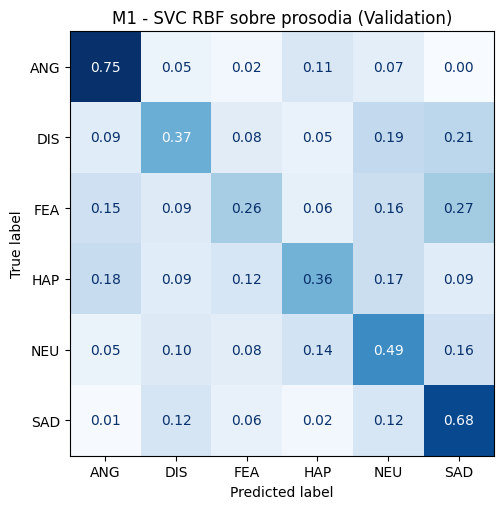

In [19]:
# ---- Entrenamiento final con probabilidades calibradas ----
m1 = Pipeline([('scaler', StandardScaler()),
               ('clf', SVC(kernel='rbf', C=C_best, gamma=gamma_best,
                           probability=True, random_state=SEED))])
m1.fit(Xtr_m1, y_train)

P_val_m1  = probs_ordenadas(m1, Xva_m1)
P_test_m1 = probs_ordenadas(m1, Xte_m1)
pred_val_m1 = pred_desde_probs(P_val_m1)

res_m1 = evaluar(y_val, pred_val_m1, 'M1_SVC_RBF', 'Prosodia y dinamica temporal (40d)')
print(pd.Series(res_m1).to_string())
print()
print(classification_report(y_val, pred_val_m1, labels=CLASSES, zero_division=0))

assert P_val_m1.shape == (len(y_val), 6)
assert np.allclose(P_val_m1.sum(axis=1), 1.0)

cm_m1 = matriz_confusion(y_val, pred_val_m1, 'M1 - SVC RBF sobre prosodia (Validation)')
print('Recall por clase:')
print(pd.Series(np.diag(cm_m1)/cm_m1.sum(axis=1), index=CLASSES).round(3).sort_values(ascending=False))

In [20]:
# ---- Persistencia ----
joblib.dump(m1, os.path.join(RUTA_MODELOS, 'modelo_m1_svc.pkl'))
np.save(os.path.join(RUTA_CSV, 'P_val_m1.npy'), P_val_m1)
np.save(os.path.join(RUTA_CSV, 'P_test_m1.npy'), P_test_m1)

df_probs = agregar_probabilidades_modelo(
    probabilidades=P_val_m1,
    clases_modelo=CLASSES,          # P_val_m1 ya viene en orden CLASSES
    num_modelo=1,
    ids_val=ids_val,
    y_val_true=y_val.values,
)
df_probs.head()

Modelo 1 anadido al CSV existente.
Guardado: ../Archivos-csv\validation_probabilities.csv  ->  (1142, 32)


,sample_id,true_label,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad,prob_model_3_anger,prob_model_3_disgust,prob_model_3_fear,prob_model_3_happy,prob_model_3_neutral,prob_model_3_sad,prob_model_4_anger,prob_model_4_disgust,prob_model_4_fear,prob_model_4_happy,prob_model_4_neutral,prob_model_4_sad,prob_model_5_anger,prob_model_5_disgust,prob_model_5_fear,prob_model_5_happy,prob_model_5_neutral,prob_model_5_sad,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad
0,1011_DFA_ANG_XX.wav,ANG,0.928014,0.029309,0.002812,0.020785,0.019016,0.000063,0.492556,0.175594,0.077468,0.237516,0.016865,0.000000,0.602,0.158,0.036,0.160,0.034,0.010,0.860019,0.135717,0.000242,0.002720,0.000188,0.001114,0.633756,0.296521,0.019511,0.040239,0.005750,0.004223
1,1011_DFA_DIS_XX.wav,DIS,0.001846,0.064145,0.023714,0.037791,0.650309,0.222195,0.026786,0.231691,0.201716,0.050537,0.228251,0.261020,0.032,0.244,0.124,0.086,0.348,0.166,0.003432,0.582204,0.032742,0.002534,0.007272,0.371815,0.051804,0.127715,0.123803,0.216378,0.228577,0.251723
2,1011_DFA_FEA_XX.wav,FEA,0.000615,0.018384,0.629102,0.046110,0.046105,0.259683,0.026667,0.186833,0.277000,0.036667,0.073333,0.399500,0.006,0.152,0.290,0.032,0.068,0.452,0.000708,0.043156,0.314402,0.001362,0.000905,0.639466,0.014780,0.292453,0.129980,0.064331,0.077013,0.421443
3,1011_DFA_HAP_XX.wav,HAP,0.003046,0.021264,0.130941,0.056101,0.409625,0.379023,0.037673,0.266773,0.205459,0.117949,0.212167,0.159979,0.028,0.206,0.156,0.139,0.291,0.180,0.003696,0.020373,0.766129,0.060240,0.007720,0.141842,0.011021,0.193131,0.099786,0.048618,0.287666,0.359777
4,1011_DFA_NEU_XX.wav,NEU,0.000349,0.058902,0.136795,0.069544,0.322691,0.411718,0.005000,0.133778,0.191611,0.026667,0.158111,0.484833,0.010,0.162,0.208,0.073,0.205,0.342,0.005738,0.036793,0.013970,0.010884,0.690067,0.242548,0.015484,0.209634,0.140936,0.101890,0.195539,0.336517


### Modelo 2

In [21]:
# =====================================================
# MODELO 2 — Regresion Logistica multinomial
# Representacion: MFCC + delta + delta2, mean + std (120 dimensiones)
# =====================================================

Xtr_m2 = X_train[vista_m2].values
Xva_m2 = X_val[vista_m2].values
Xte_m2 = X_test[vista_m2].values
print(f'Train {Xtr_m2.shape} | Val {Xva_m2.shape} | Test {Xte_m2.shape}')

# ---- Busqueda de hiperparametros SOBRE VALIDATION ----
resultados_grid_m2 = []
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(C=C, max_iter=3000, random_state=SEED))])
    m.fit(Xtr_m2, y_train)
    pred = m.predict(Xva_m2)
    resultados_grid_m2.append({
        'C': C,
        'Accuracy': accuracy_score(y_val, pred),
        'Macro F1': f1_score(y_val, pred, average='macro', labels=CLASSES, zero_division=0),
    })

grid_m2 = pd.DataFrame(resultados_grid_m2).sort_values('Macro F1', ascending=False)
print(grid_m2.to_string(index=False))

mejor_m2 = grid_m2.iloc[0]
C_best_m2 = mejor_m2['C']
print(f"\nMejor configuracion: C={C_best_m2}")

Train (5152, 120) | Val (1142, 120) | Test (1148, 120)
      C  Accuracy  Macro F1
 10.000  0.515762  0.509457
100.000  0.513135  0.506913
  1.000  0.512259  0.506036
  0.100  0.507005  0.500952
  0.010  0.489492  0.477747
  0.001  0.454466  0.429171

Mejor configuracion: C=10.0


Modelo                                     M2_LogReg
Representacion     MFCC+delta+delta2 mean+std (120d)
Accuracy                                    0.515762
Macro Precision                             0.515528
Macro Recall                                0.514596
Macro F1                                    0.509457
Weighted F1                                 0.511353

              precision    recall  f1-score   support

         ANG       0.67      0.70      0.69       195
         DIS       0.42      0.36      0.39       195
         FEA       0.60      0.43      0.50       195
         HAP       0.48      0.44      0.46       195
         NEU       0.40      0.47      0.43       167
         SAD       0.52      0.69      0.59       195

    accuracy                           0.52      1142
   macro avg       0.52      0.51      0.51      1142
weighted avg       0.52      0.52      0.51      1142

Discrepancia predict() vs argmax(proba): 0.00%
Recall por clase:
ANG    0.703
SAD    

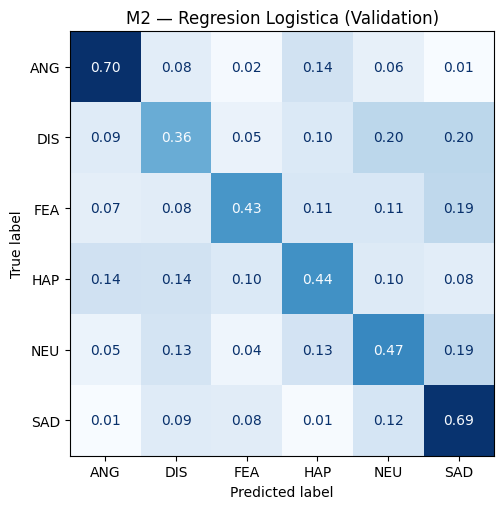

In [22]:
# ---- Entrenamiento final ----
m2 = Pipeline([('scaler', StandardScaler()),
               ('clf', LogisticRegression(C=C_best_m2, max_iter=3000, random_state=SEED))])
m2.fit(Xtr_m2, y_train)

P_val_m2  = probs_ordenadas(m2, Xva_m2)
P_test_m2 = probs_ordenadas(m2, Xte_m2)
pred_val_m2 = pred_desde_probs(P_val_m2)

res_m2 = evaluar(y_val, pred_val_m2, 'M2_LogReg', 'MFCC+delta+delta2 mean+std (120d)')
print(pd.Series(res_m2).to_string())
print()
print(classification_report(y_val, pred_val_m2, labels=CLASSES, zero_division=0))

# Comprobaciones de integridad
assert P_val_m2.shape == (len(y_val), 6)
assert np.allclose(P_val_m2.sum(axis=1), 1.0)
print(f"Discrepancia predict() vs argmax(proba): "
      f"{100*(m2.predict(Xva_m2) != pred_val_m2).mean():.2f}%")

cm_m2 = matriz_confusion(y_val, pred_val_m2, 'M2 — Regresion Logistica (Validation)')
print('Recall por clase:')
print(pd.Series(np.diag(cm_m2)/cm_m2.sum(axis=1), index=CLASSES).round(3).sort_values(ascending=False))

In [23]:
# ---- Persistencia ----
joblib.dump(m2, os.path.join(RUTA_MODELOS, 'modelo_m2_logreg.pkl'))
np.save(os.path.join(RUTA_CSV, 'P_val_m2.npy'), P_val_m2)
np.save(os.path.join(RUTA_CSV, 'P_test_m2.npy'), P_test_m2)

df_probs = agregar_probabilidades_modelo(
    probabilidades=P_val_m2,
    clases_modelo=CLASSES,          # P_val_m2 ya viene en orden CLASSES
    num_modelo=2,
    ids_val=ids_val,
    y_val_true=y_val.values,
)
df_probs.head()

Modelo 2 anadido al CSV existente.
Guardado: ../Archivos-csv\validation_probabilities.csv  ->  (1142, 32)


,sample_id,true_label,prob_model_3_anger,prob_model_3_disgust,prob_model_3_fear,prob_model_3_happy,prob_model_3_neutral,prob_model_3_sad,prob_model_4_anger,prob_model_4_disgust,prob_model_4_fear,prob_model_4_happy,prob_model_4_neutral,prob_model_4_sad,prob_model_5_anger,prob_model_5_disgust,prob_model_5_fear,prob_model_5_happy,prob_model_5_neutral,prob_model_5_sad,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad
0,1011_DFA_ANG_XX.wav,ANG,0.492556,0.175594,0.077468,0.237516,0.016865,0.000000,0.602,0.158,0.036,0.160,0.034,0.010,0.860019,0.135717,0.000242,0.002720,0.000188,0.001114,0.633756,0.296521,0.019511,0.040239,0.005750,0.004223,0.928014,0.029309,0.002812,0.020785,0.019016,0.000063
1,1011_DFA_DIS_XX.wav,DIS,0.026786,0.231691,0.201716,0.050537,0.228251,0.261020,0.032,0.244,0.124,0.086,0.348,0.166,0.003432,0.582204,0.032742,0.002534,0.007272,0.371815,0.051804,0.127715,0.123803,0.216378,0.228577,0.251723,0.001846,0.064145,0.023714,0.037791,0.650309,0.222195
2,1011_DFA_FEA_XX.wav,FEA,0.026667,0.186833,0.277000,0.036667,0.073333,0.399500,0.006,0.152,0.290,0.032,0.068,0.452,0.000708,0.043156,0.314402,0.001362,0.000905,0.639466,0.014780,0.292453,0.129980,0.064331,0.077013,0.421443,0.000615,0.018384,0.629102,0.046110,0.046105,0.259683
3,1011_DFA_HAP_XX.wav,HAP,0.037673,0.266773,0.205459,0.117949,0.212167,0.159979,0.028,0.206,0.156,0.139,0.291,0.180,0.003696,0.020373,0.766129,0.060240,0.007720,0.141842,0.011021,0.193131,0.099786,0.048618,0.287666,0.359777,0.003046,0.021264,0.130941,0.056101,0.409625,0.379023
4,1011_DFA_NEU_XX.wav,NEU,0.005000,0.133778,0.191611,0.026667,0.158111,0.484833,0.010,0.162,0.208,0.073,0.205,0.342,0.005738,0.036793,0.013970,0.010884,0.690067,0.242548,0.015484,0.209634,0.140936,0.101890,0.195539,0.336517,0.000349,0.058902,0.136795,0.069544,0.322691,0.411718


### Modelo 3  


In [24]:
# =====================================================
# MODELO 3 — Random Forest
# Representacion: MFCC mean + std + 7 caracteristicas espectrales (27 dimensiones)
# =====================================================

Xtr_m3 = X_train[vista_m3].values
Xva_m3 = X_val[vista_m3].values
Xte_m3 = X_test[vista_m3].values

print(f'Train {Xtr_m3.shape} | Val {Xva_m3.shape} | Test {Xte_m3.shape}')

# ---- Busqueda de hiperparametros SOBRE VALIDATION ----
resultados_grid_m3 = []
for n_est in [100, 200, 300]:
    for depth in [10, 20, 30]:
        m = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(
                n_estimators=n_est, 
                max_depth=depth, 
                random_state=SEED, 
                n_jobs=-1
            ))
        ])
        m.fit(Xtr_m3, y_train)
        pred = m.predict(Xva_m3)
        resultados_grid_m3.append({
            'n_estimators': n_est,
            'max_depth': depth,
            'Accuracy': accuracy_score(y_val, pred),
            'Macro F1': f1_score(y_val, pred, average='macro', labels=CLASSES, zero_division=0),
        })

grid_m3 = pd.DataFrame(resultados_grid_m3).sort_values('Macro F1', ascending=False)
print(grid_m3.to_string(index=False))

mejor_m3 = grid_m3.iloc[0]
# Se convierte a int() porque pandas transforma la fila a float al mezclarla con Accuracy y Macro F1
n_est_best_m3 = int(mejor_m3['n_estimators'])
depth_best_m3 = int(mejor_m3['max_depth'])

print(f"\nMejor configuracion: n_estimators={n_est_best_m3}, max_depth={depth_best_m3}")

Train (5152, 27) | Val (1142, 27) | Test (1148, 27)
 n_estimators  max_depth  Accuracy  Macro F1
          300         20  0.478109  0.455417
          300         30  0.476357  0.455187
          200         20  0.470228  0.448378
          100         30  0.464974  0.447603
          300         10  0.472855  0.447207
          100         20  0.467601  0.447059
          200         30  0.465849  0.445161
          200         10  0.470228  0.444551
          100         10  0.460595  0.436410

Mejor configuracion: n_estimators=300, max_depth=20


Modelo                      M3_RandomForest
Representacion     MFCC + Espectrales (27d)
Accuracy                           0.478109
Macro Precision                    0.495072
Macro Recall                       0.477988
Macro F1                           0.455417
Weighted F1                        0.457065

              precision    recall  f1-score   support

         ANG       0.63      0.72      0.67       195
         DIS       0.46      0.38      0.42       195
         FEA       0.64      0.16      0.26       195
         HAP       0.40      0.36      0.38       195
         NEU       0.33      0.47      0.39       167
         SAD       0.52      0.77      0.62       195

    accuracy                           0.48      1142
   macro avg       0.50      0.48      0.46      1142
weighted avg       0.50      0.48      0.46      1142

Discrepancia predict() vs argmax(proba): 0.00%
Recall por clase:
SAD    0.769
ANG    0.723
NEU    0.473
DIS    0.379
HAP    0.359
FEA    0.164
dtype

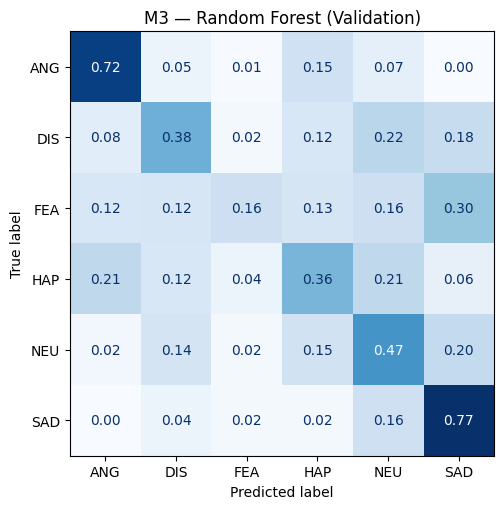

In [25]:
# ---- Entrenamiento final y extracción de probabilidades (Modelo 3) ----
m3 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=n_est_best_m3, 
        max_depth=depth_best_m3,
        random_state=SEED, 
        n_jobs=-1
    ))
])
m3.fit(Xtr_m3, y_train)

P_val_m3  = probs_ordenadas(m3, Xva_m3)
P_test_m3 = probs_ordenadas(m3, Xte_m3)
pred_val_m3 = pred_desde_probs(P_val_m3)

res_m3 = evaluar(y_val, pred_val_m3, 'M3_RandomForest', 'MFCC + Espectrales (27d)')
print(pd.Series(res_m3).to_string())
print()
print(classification_report(y_val, pred_val_m3, labels=CLASSES, zero_division=0))

# Comprobaciones de integridad
assert P_val_m3.shape == (len(y_val), 6)
assert np.allclose(P_val_m3.sum(axis=1), 1.0)
print(f"Discrepancia predict() vs argmax(proba): "
      f"{100*(m3.predict(Xva_m3) != pred_val_m3).mean():.2f}%")

cm_m3 = matriz_confusion(y_val, pred_val_m3, 'M3 — Random Forest (Validation)')
print('Recall por clase:')
print(pd.Series(np.diag(cm_m3)/cm_m3.sum(axis=1), index=CLASSES).round(3).sort_values(ascending=False))

In [26]:
# ---- Persistencia (Modelo 3) ----
joblib.dump(m3, os.path.join(RUTA_MODELOS, 'modelo_m3_rf.pkl'))
np.save(os.path.join(RUTA_CSV, 'P_val_m3.npy'), P_val_m3)
np.save(os.path.join(RUTA_CSV, 'P_test_m3.npy'), P_test_m3)

df_probs = agregar_probabilidades_modelo(
    probabilidades=P_val_m3,
    clases_modelo=CLASSES,          # P_val_m3 ya viene en orden CLASSES
    num_modelo=3,
    ids_val=ids_val,
    y_val_true=y_val.values,
)
df_probs.head()

Modelo 3 anadido al CSV existente.
Guardado: ../Archivos-csv\validation_probabilities.csv  ->  (1142, 32)


,sample_id,true_label,prob_model_4_anger,prob_model_4_disgust,prob_model_4_fear,prob_model_4_happy,prob_model_4_neutral,prob_model_4_sad,prob_model_5_anger,prob_model_5_disgust,prob_model_5_fear,prob_model_5_happy,prob_model_5_neutral,prob_model_5_sad,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad,prob_model_3_anger,prob_model_3_disgust,prob_model_3_fear,prob_model_3_happy,prob_model_3_neutral,prob_model_3_sad
0,1011_DFA_ANG_XX.wav,ANG,0.602,0.158,0.036,0.160,0.034,0.010,0.860019,0.135717,0.000242,0.002720,0.000188,0.001114,0.633756,0.296521,0.019511,0.040239,0.005750,0.004223,0.928014,0.029309,0.002812,0.020785,0.019016,0.000063,0.492556,0.175594,0.077468,0.237516,0.016865,0.000000
1,1011_DFA_DIS_XX.wav,DIS,0.032,0.244,0.124,0.086,0.348,0.166,0.003432,0.582204,0.032742,0.002534,0.007272,0.371815,0.051804,0.127715,0.123803,0.216378,0.228577,0.251723,0.001846,0.064145,0.023714,0.037791,0.650309,0.222195,0.026786,0.231691,0.201716,0.050537,0.228251,0.261020
2,1011_DFA_FEA_XX.wav,FEA,0.006,0.152,0.290,0.032,0.068,0.452,0.000708,0.043156,0.314402,0.001362,0.000905,0.639466,0.014780,0.292453,0.129980,0.064331,0.077013,0.421443,0.000615,0.018384,0.629102,0.046110,0.046105,0.259683,0.026667,0.186833,0.277000,0.036667,0.073333,0.399500
3,1011_DFA_HAP_XX.wav,HAP,0.028,0.206,0.156,0.139,0.291,0.180,0.003696,0.020373,0.766129,0.060240,0.007720,0.141842,0.011021,0.193131,0.099786,0.048618,0.287666,0.359777,0.003046,0.021264,0.130941,0.056101,0.409625,0.379023,0.037673,0.266773,0.205459,0.117949,0.212167,0.159979
4,1011_DFA_NEU_XX.wav,NEU,0.010,0.162,0.208,0.073,0.205,0.342,0.005738,0.036793,0.013970,0.010884,0.690067,0.242548,0.015484,0.209634,0.140936,0.101890,0.195539,0.336517,0.000349,0.058902,0.136795,0.069544,0.322691,0.411718,0.005000,0.133778,0.191611,0.026667,0.158111,0.484833


### Modelo 4

In [27]:
# MODELO 4 — Extra Trees (Extremely Randomized Trees)
# Representacion: todas las caracteristicas (127 dimensiones)
# =====================================================

Xtr_m4 = X_train[vista_m4].values
Xva_m4 = X_val[vista_m4].values
Xte_m4 = X_test[vista_m4].values
print(f'Train {Xtr_m4.shape} | Val {Xva_m4.shape} | Test {Xte_m4.shape}')

# ---- Busqueda de hiperparametros SOBRE VALIDATION ----
# Los arboles no necesitan StandardScaler: no dependen de la escala.
resultados_grid_m4 = []
for n_est in [200, 500]:
    for max_depth in [None, 20]:
        for min_leaf in [1, 3]:
            m = ExtraTreesClassifier(n_estimators=n_est, max_depth=max_depth,
                                     min_samples_leaf=min_leaf,
                                     n_jobs=-1, random_state=SEED)
            m.fit(Xtr_m4, y_train)
            pred = m.predict(Xva_m4)
            resultados_grid_m4.append({
                'n_estimators': n_est, 'max_depth': max_depth, 'min_samples_leaf': min_leaf,
                'Accuracy': accuracy_score(y_val, pred),
                'Macro F1': f1_score(y_val, pred, average='macro', labels=CLASSES, zero_division=0),
            })

grid_m4 = pd.DataFrame(resultados_grid_m4).sort_values('Macro F1', ascending=False)
print(grid_m4.to_string(index=False))

mejor_m4 = grid_m4.iloc[0]
n_est_best_m4  = int(mejor_m4['n_estimators'])
depth_best_m4  = None if pd.isna(mejor_m4['max_depth']) else int(mejor_m4['max_depth'])
leaf_best_m4   = int(mejor_m4['min_samples_leaf'])
print(f"\nMejor configuracion: n_estimators={n_est_best_m4}, "
      f"max_depth={depth_best_m4}, min_samples_leaf={leaf_best_m4}")

Train (5152, 127) | Val (1142, 127) | Test (1148, 127)
 n_estimators  max_depth  min_samples_leaf  Accuracy  Macro F1
          500        NaN                 1  0.497373  0.476784
          500       20.0                 3  0.493870  0.468830
          200        NaN                 1  0.488616  0.466755
          200       20.0                 3  0.479860  0.453339
          500        NaN                 3  0.480736  0.453056
          200       20.0                 1  0.471103  0.446446
          500       20.0                 1  0.470228  0.443468
          200        NaN                 3  0.465849  0.436054

Mejor configuracion: n_estimators=500, max_depth=None, min_samples_leaf=1


Modelo                                M4_ExtraTrees
Representacion     Todas las caracteristicas (127d)
Accuracy                                   0.497373
Macro Precision                            0.501709
Macro Recall                               0.498081
Macro F1                                   0.476784
Weighted F1                                0.477494

              precision    recall  f1-score   support

         ANG       0.60      0.80      0.69       195
         DIS       0.42      0.32      0.36       195
         FEA       0.60      0.23      0.33       195
         HAP       0.49      0.41      0.45       195
         NEU       0.39      0.53      0.45       167
         SAD       0.50      0.71      0.59       195

    accuracy                           0.50      1142
   macro avg       0.50      0.50      0.48      1142
weighted avg       0.50      0.50      0.48      1142

Discrepancia predict() vs argmax(proba): 0.00%
Recall por clase:
ANG    0.800
SAD    0.713
N

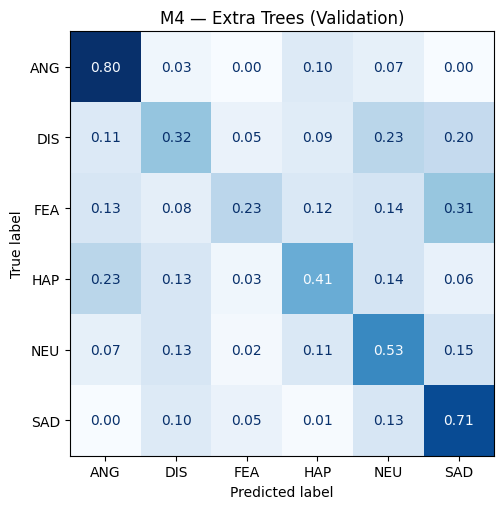

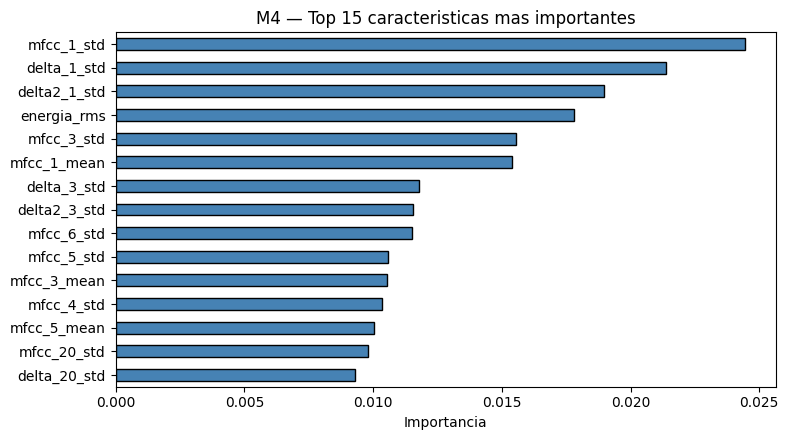

In [28]:
# ---- Entrenamiento final ----
m4 = ExtraTreesClassifier(n_estimators=n_est_best_m4, max_depth=depth_best_m4,
                          min_samples_leaf=leaf_best_m4,
                          n_jobs=-1, random_state=SEED)
m4.fit(Xtr_m4, y_train)

P_val_m4  = probs_ordenadas(m4, Xva_m4)
P_test_m4 = probs_ordenadas(m4, Xte_m4)
pred_val_m4 = pred_desde_probs(P_val_m4)

res_m4 = evaluar(y_val, pred_val_m4, 'M4_ExtraTrees', 'Todas las caracteristicas (127d)')
print(pd.Series(res_m4).to_string())
print()
print(classification_report(y_val, pred_val_m4, labels=CLASSES, zero_division=0))

# Comprobaciones de integridad
assert P_val_m4.shape == (len(y_val), 6)
assert np.allclose(P_val_m4.sum(axis=1), 1.0)
print(f"Discrepancia predict() vs argmax(proba): "
      f"{100*(m4.predict(Xva_m4) != pred_val_m4).mean():.2f}%")

cm_m4 = matriz_confusion(y_val, pred_val_m4, 'M4 — Extra Trees (Validation)')
print('Recall por clase:')
print(pd.Series(np.diag(cm_m4)/cm_m4.sum(axis=1), index=CLASSES).round(3).sort_values(ascending=False))

# ---- Importancia de caracteristicas (top 15) ----
imp = pd.Series(m4.feature_importances_, index=vista_m4).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 4.5))
imp[::-1].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('M4 — Top 15 caracteristicas mas importantes'); plt.xlabel('Importancia')
plt.tight_layout(); plt.show()

In [29]:
# ---- Persistencia ----
import joblib
joblib.dump(m4, os.path.join(RUTA_MODELOS, 'modelo_m4_extratrees_compress.pkl'), compress=3)
np.save(os.path.join(RUTA_CSV, 'P_val_m4.npy'), P_val_m4)
np.save(os.path.join(RUTA_CSV, 'P_test_m4.npy'), P_test_m4)

df_probs = agregar_probabilidades_modelo(
    probabilidades=P_val_m4,
    clases_modelo=CLASSES,          # P_val_m4 ya viene en orden CLASSES
    num_modelo=4,
    ids_val=ids_val,
    y_val_true=y_val.values,
)
df_probs.head()

Modelo 4 anadido al CSV existente.
Guardado: ../Archivos-csv\validation_probabilities.csv  ->  (1142, 32)


,sample_id,true_label,prob_model_5_anger,prob_model_5_disgust,prob_model_5_fear,prob_model_5_happy,prob_model_5_neutral,prob_model_5_sad,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad,prob_model_3_anger,prob_model_3_disgust,prob_model_3_fear,prob_model_3_happy,prob_model_3_neutral,prob_model_3_sad,prob_model_4_anger,prob_model_4_disgust,prob_model_4_fear,prob_model_4_happy,prob_model_4_neutral,prob_model_4_sad
0,1011_DFA_ANG_XX.wav,ANG,0.860019,0.135717,0.000242,0.002720,0.000188,0.001114,0.633756,0.296521,0.019511,0.040239,0.005750,0.004223,0.928014,0.029309,0.002812,0.020785,0.019016,0.000063,0.492556,0.175594,0.077468,0.237516,0.016865,0.000000,0.602,0.158,0.036,0.160,0.034,0.010
1,1011_DFA_DIS_XX.wav,DIS,0.003432,0.582204,0.032742,0.002534,0.007272,0.371815,0.051804,0.127715,0.123803,0.216378,0.228577,0.251723,0.001846,0.064145,0.023714,0.037791,0.650309,0.222195,0.026786,0.231691,0.201716,0.050537,0.228251,0.261020,0.032,0.244,0.124,0.086,0.348,0.166
2,1011_DFA_FEA_XX.wav,FEA,0.000708,0.043156,0.314402,0.001362,0.000905,0.639466,0.014780,0.292453,0.129980,0.064331,0.077013,0.421443,0.000615,0.018384,0.629102,0.046110,0.046105,0.259683,0.026667,0.186833,0.277000,0.036667,0.073333,0.399500,0.006,0.152,0.290,0.032,0.068,0.452
3,1011_DFA_HAP_XX.wav,HAP,0.003696,0.020373,0.766129,0.060240,0.007720,0.141842,0.011021,0.193131,0.099786,0.048618,0.287666,0.359777,0.003046,0.021264,0.130941,0.056101,0.409625,0.379023,0.037673,0.266773,0.205459,0.117949,0.212167,0.159979,0.028,0.206,0.156,0.139,0.291,0.180
4,1011_DFA_NEU_XX.wav,NEU,0.005738,0.036793,0.013970,0.010884,0.690067,0.242548,0.015484,0.209634,0.140936,0.101890,0.195539,0.336517,0.000349,0.058902,0.136795,0.069544,0.322691,0.411718,0.005000,0.133778,0.191611,0.026667,0.158111,0.484833,0.010,0.162,0.208,0.073,0.205,0.342


### Modelo 5

**Representacion: espectrograma log-mel (64 x 94), no el CSV de caracteristicas.**

Los modelos 1 a 4 usan `features_cremad.csv`: 127 numeros por audio (medias y
desviaciones de MFCC y descriptores espectrales). Esa tabla ya colapso el eje
temporal, asi que no hay nada que convolucionar.

Un CNN necesita una entrada con estructura local, asi que aqui se parte de nuevo
desde el audio y se calcula el espectrograma log-mel: una imagen de 64 bandas de
frecuencia x 94 ventanas de tiempo. El CNN aprende solo que filtros extraer, en vez
de recibir estadisticos ya resumidos.

Esto tambien es lo que le da **diversidad al ensamble**: M1 y M2 estan correlacionados
0.79 porque ambos salen de los mismos MFCC. Al partir de una representacion distinta,
el M5 se equivoca en audios distintos y el promedio del ensamble si aporta.

Al ser deep learning, aqui si se usa *validation* como pide la celda de instrucciones:
early stopping, `ReduceLROnPlateau` y se guarda el mejor checkpoint.

In [30]:
# =====================================================
# MODELO 5 - CNN 2D sobre espectrogramas log-mel
# =====================================================
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)
torch.set_num_threads(os.cpu_count() or 4)

# Usa la GPU si hay una build de PyTorch con CUDA; si no, CPU.
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DISPOSITIVO}'
      + (f' ({torch.cuda.get_device_name(0)})' if DISPOSITIVO.type == 'cuda' else ''))

N_MELS, N_FFT, HOP = 64, 1024, 512
RUTA_MELS = os.path.join(RUTA_CSV, 'mels_cremad.npy')


def log_mel(wav):
    S = librosa.feature.melspectrogram(y=wav, sr=SR, n_fft=N_FFT,
                                       hop_length=HOP, n_mels=N_MELS)
    return librosa.power_to_db(S, ref=np.max).astype(np.float32)


# Se recorren los audios en el MISMO orden que df_caracteristicas (ordenado por
# sample_id), para que idx_train/idx_val/idx_test valgan tal cual.
if os.path.exists(RUTA_MELS):
    X_mel = np.load(RUTA_MELS)
    print(f'Espectrogramas cargados de cache: {X_mel.shape}')
else:
    t0 = time.time()
    X_mel = np.zeros((len(df_caracteristicas), N_MELS, 1 + N_MUESTRAS // HOP),
                     dtype=np.float32)
    for i, sid in enumerate(df_caracteristicas['sample_id']):
        wav, _ = pad_or_truncate_audio(os.path.join(DATASET_ROOT, sid))
        X_mel[i] = log_mel(wav)
        if (i + 1) % 1000 == 0:
            print(f'  {i+1}/{len(df_caracteristicas)}  ({time.time()-t0:.0f}s)')
    np.save(RUTA_MELS, X_mel)
    print(f'Espectrogramas calculados {X_mel.shape} en {time.time()-t0:.0f}s')

Dispositivo: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)
Espectrogramas cargados de cache: (7442, 64, 94)


In [31]:
# ---- Particiones + normalizacion ----
# La media y desviacion salen SOLO de train: usar el dataset completo seria
# fuga de informacion de val/test hacia el entrenamiento.

cls2i = {c: i for i, c in enumerate(CLASSES)}
y_idx = df_caracteristicas['emocion'].map(cls2i).values.astype(np.int64)

mu, sd = X_mel[idx_train].mean(), X_mel[idx_train].std()
print(f'Normalizacion (solo train): mu={mu:.3f}  sd={sd:.3f}')


def a_tensores(idx):
    return (torch.from_numpy((X_mel[idx] - mu) / sd).unsqueeze(1),
            torch.from_numpy(y_idx[idx]))


Xtr_m5, ytr_m5 = a_tensores(idx_train)
Xva_m5, yva_m5 = a_tensores(idx_val)
Xte_m5, yte_m5 = a_tensores(idx_test)
print(f'Train {tuple(Xtr_m5.shape)} | Val {tuple(Xva_m5.shape)} | Test {tuple(Xte_m5.shape)}')

Normalizacion (solo train): mu=-48.246  sd=15.594
Train (5152, 1, 64, 94) | Val (1142, 1, 64, 94) | Test (1148, 1, 64, 94)


In [32]:
# ---- Arquitectura ----
class CNNEmocion(nn.Module):
    """Tres bloques conv-conv-pool y global average pooling.

    El GAP en vez de un Flatten mantiene la cabeza pequena (~300k parametros en
    total): con solo 5152 audios de entrenamiento, una capa densa sobre el mapa
    aplanado sobreajustaria de inmediato.
    """

    def __init__(self, n_clases=6):
        super().__init__()

        def bloque(ent, sal):
            return nn.Sequential(
                nn.Conv2d(ent, sal, 3, padding=1, bias=False),
                nn.BatchNorm2d(sal), nn.ReLU(inplace=True),
                nn.Conv2d(sal, sal, 3, padding=1, bias=False),
                nn.BatchNorm2d(sal), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))

        self.rasgos = nn.Sequential(bloque(1, 32), bloque(32, 64), bloque(64, 128))
        self.cabeza = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(128, 64), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(64, n_clases))

    def forward(self, x):
        h = self.rasgos(x)
        h = F.adaptive_avg_pool2d(h, 1).flatten(1)
        return self.cabeza(h)


def spec_augment(lote, max_f=12, max_t=16):
    """SpecAugment: tapa bandas de frecuencia y tramos de tiempo al azar.

    Obliga a la red a no depender de una sola banda y es la regularizacion
    estandar en audio. Solo se aplica en entrenamiento.
    """
    lote = lote.clone()
    B, _, Fq, T = lote.shape
    for i in range(B):
        f = np.random.randint(0, max_f)
        f0 = np.random.randint(0, max(1, Fq - f))
        lote[i, :, f0:f0 + f, :] = 0
        t = np.random.randint(0, max_t)
        t0 = np.random.randint(0, max(1, T - t))
        lote[i, :, :, t0:t0 + t] = 0
    return lote


m5 = CNNEmocion().to(DISPOSITIVO)
print(f'Parametros entrenables: {sum(p.numel() for p in m5.parameters()):,}')

Parametros entrenables: 295,526


ep   1 | loss 1.5728 | val acc 0.2312 | val macroF1 0.1529 | lr 2.0e-03  <-- mejor (guardado)
ep   2 | loss 1.5170 | val acc 0.3993 | val macroF1 0.3404 | lr 2.0e-03  <-- mejor (guardado)
ep   3 | loss 1.4664 | val acc 0.3984 | val macroF1 0.3303 | lr 2.0e-03
ep   4 | loss 1.4349 | val acc 0.3573 | val macroF1 0.2466 | lr 2.0e-03
ep   5 | loss 1.4272 | val acc 0.3135 | val macroF1 0.2423 | lr 2.0e-03
ep   6 | loss 1.4098 | val acc 0.4650 | val macroF1 0.4310 | lr 2.0e-03  <-- mejor (guardado)
ep   7 | loss 1.3704 | val acc 0.3485 | val macroF1 0.3023 | lr 2.0e-03
ep   8 | loss 1.3705 | val acc 0.3091 | val macroF1 0.2732 | lr 2.0e-03
ep   9 | loss 1.3611 | val acc 0.4772 | val macroF1 0.4807 | lr 2.0e-03  <-- mejor (guardado)
ep  10 | loss 1.3401 | val acc 0.4422 | val macroF1 0.3895 | lr 2.0e-03
ep  11 | loss 1.3325 | val acc 0.3581 | val macroF1 0.2705 | lr 2.0e-03
ep  12 | loss 1.3149 | val acc 0.3669 | val macroF1 0.3293 | lr 2.0e-03
ep  13 | loss 1.3016 | val acc 0.5306 | val macr

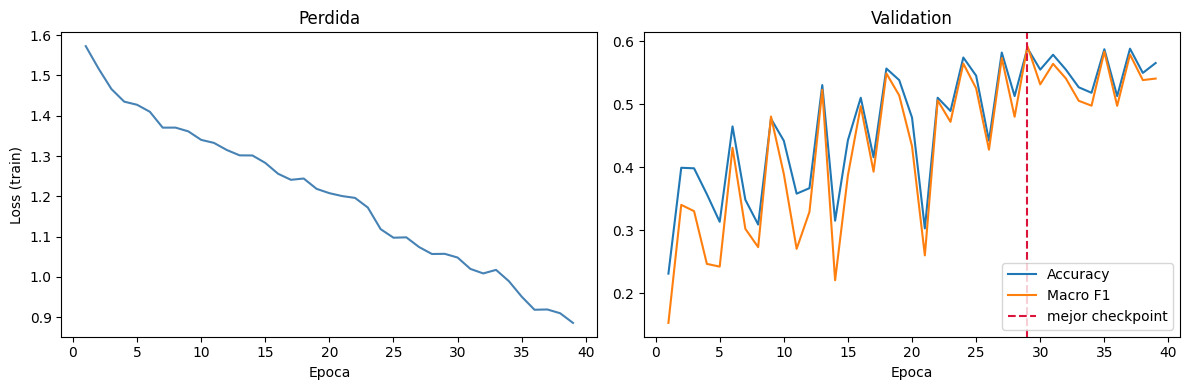

In [33]:
# ---- Entrenamiento con early stopping sobre VALIDATION ----
EPOCAS, LOTE, PACIENCIA = 60, 64, 10

opt = torch.optim.AdamW(m5.parameters(), lr=2e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=4)
crit = nn.CrossEntropyLoss(label_smoothing=0.05)


@torch.no_grad()
def probs_cnn(modelo, Xt, lote=256):
    """Probabilidades softmax, ya en el orden de CLASSES."""
    modelo.eval()
    salidas = [F.softmax(modelo(Xt[i:i + lote].to(DISPOSITIVO)), dim=1).cpu()
               for i in range(0, len(Xt), lote)]
    return torch.cat(salidas).numpy()


RUTA_M5 = os.path.join(RUTA_MODELOS, 'modelo_m5_cnn.pt')


def guardar_checkpoint():
    """Escribe el mejor modelo a disco en cuanto mejora.

    Asi, si se interrumpe el entrenamiento (kernel caido, Ctrl-C, cierre del
    notebook), queda en disco el mejor modelo hasta ese momento en vez de
    perderse todo. El state_dict se pasa a CPU para que el .pt se pueda cargar
    tambien en una maquina sin GPU.
    """
    torch.save({'state_dict': {k: v.cpu() for k, v in m5.state_dict().items()},
                'mu': float(mu), 'sd': float(sd), 'classes': CLASSES,
                'n_mels': N_MELS, 'n_fft': N_FFT, 'hop': HOP,
                'epoca': ep, 'val_macro_f1': float(f1)}, RUTA_M5)


mejor_f1, mejor_estado, sin_mejora = -1.0, None, 0
hist = []
gen = torch.Generator().manual_seed(SEED)
t0 = time.time()

for ep in range(1, EPOCAS + 1):
    m5.train()
    perm = torch.randperm(len(Xtr_m5), generator=gen)
    perdida = 0.0
    for i in range(0, len(perm), LOTE):
        b = perm[i:i + LOTE]
        xb = spec_augment(Xtr_m5[b]).to(DISPOSITIVO)
        yb = ytr_m5[b].to(DISPOSITIVO)
        opt.zero_grad()
        loss = crit(m5(xb), yb)
        loss.backward()
        opt.step()
        perdida += loss.item() * len(b)

    P = probs_cnn(m5, Xva_m5)
    pred = P.argmax(1)
    f1 = f1_score(yva_m5.numpy(), pred, average='macro', zero_division=0)
    acc = accuracy_score(yva_m5.numpy(), pred)
    sched.step(f1)
    hist.append({'epoca': ep, 'loss': perdida / len(perm), 'val_acc': acc, 'val_f1': f1})

    marca = ''
    if f1 > mejor_f1:
        mejor_f1, sin_mejora = f1, 0
        # checkpoint: se guarda el mejor estado, no el ultimo
        mejor_estado = {k: v.clone() for k, v in m5.state_dict().items()}
        guardar_checkpoint()
        marca = '  <-- mejor (guardado)'
    else:
        sin_mejora += 1

    print(f'ep {ep:3d} | loss {perdida/len(perm):.4f} | val acc {acc:.4f} | '
          f'val macroF1 {f1:.4f} | lr {opt.param_groups[0]["lr"]:.1e}{marca}')

    if sin_mejora >= PACIENCIA:
        print(f'Early stopping en la epoca {ep} (sin mejora en {PACIENCIA} epocas)')
        break

print(f'\nEntrenamiento: {time.time()-t0:.0f}s | mejor val Macro F1 = {mejor_f1:.4f}')
m5.load_state_dict(mejor_estado)   # se restaura el mejor checkpoint

# ---- Curvas de entrenamiento ----
h = pd.DataFrame(hist)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['epoca'], h['loss'], color='steelblue')
ax[0].set_xlabel('Epoca'); ax[0].set_ylabel('Loss (train)'); ax[0].set_title('Perdida')
ax[1].plot(h['epoca'], h['val_acc'], label='Accuracy')
ax[1].plot(h['epoca'], h['val_f1'], label='Macro F1')
ax[1].axvline(h.loc[h['val_f1'].idxmax(), 'epoca'], color='crimson', ls='--',
              label='mejor checkpoint')
ax[1].set_xlabel('Epoca'); ax[1].set_title('Validation'); ax[1].legend()
plt.tight_layout(); plt.show()

Modelo                    M5_CNN
Representacion     Log-mel 64x94
Accuracy                0.589317
Macro Precision         0.623555
Macro Recall            0.587824
Macro F1                0.592427
Weighted F1             0.591864

              precision    recall  f1-score   support

         ANG       0.88      0.57      0.69       195
         DIS       0.53      0.64      0.58       195
         FEA       0.56      0.46      0.51       195
         HAP       0.52      0.61      0.56       195
         NEU       0.74      0.53      0.62       167
         SAD       0.51      0.72      0.60       195

    accuracy                           0.59      1142
   macro avg       0.62      0.59      0.59      1142
weighted avg       0.62      0.59      0.59      1142

Recall por clase:
SAD    0.723
DIS    0.636
HAP    0.605
ANG    0.574
NEU    0.527
FEA    0.462
dtype: float64


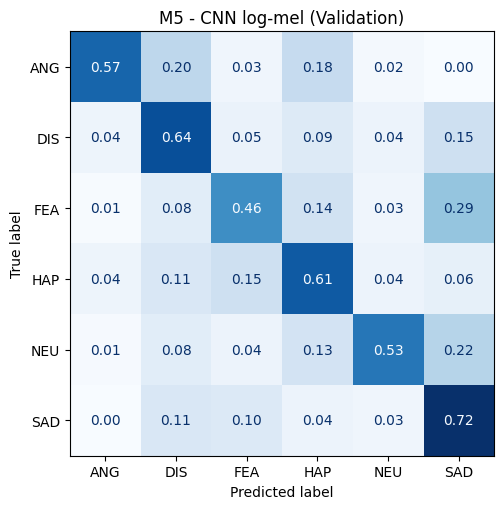

In [34]:
# ---- Evaluacion ----
P_val_m5 = probs_cnn(m5, Xva_m5)
P_test_m5 = probs_cnn(m5, Xte_m5)
pred_val_m5 = pred_desde_probs(P_val_m5)   # devuelve etiquetas de texto

res_m5 = evaluar(y_val, pred_val_m5, 'M5_CNN', 'Log-mel 64x94')
print(pd.Series(res_m5).to_string())
print()
print(classification_report(y_val, pred_val_m5, labels=CLASSES, zero_division=0))

assert P_val_m5.shape == (len(y_val), 6)
assert np.allclose(P_val_m5.sum(axis=1), 1.0, atol=1e-5)

cm_m5 = matriz_confusion(y_val, pred_val_m5, 'M5 - CNN log-mel (Validation)')
print('Recall por clase:')
print(pd.Series(np.diag(cm_m5) / cm_m5.sum(axis=1), index=CLASSES).round(3).sort_values(ascending=False))

In [35]:
# ---- Persistencia ----
# El .pt ya quedo escrito durante el entrenamiento (guardar_checkpoint lo
# actualiza en cada mejora), asi que aqui solo se confirma y se guardan las
# probabilidades. Un modelo de PyTorch no se serializa con joblib: se guarda el
# state_dict junto con mu/sd, que hacen falta para inferir sobre audio nuevo.
ck = torch.load(RUTA_M5, map_location='cpu', weights_only=False)
print(f"Checkpoint en disco: epoca {ck['epoca']}, val Macro F1 {ck['val_macro_f1']:.4f}")

np.save(os.path.join(RUTA_CSV, 'P_val_m5.npy'), P_val_m5)
np.save(os.path.join(RUTA_CSV, 'P_test_m5.npy'), P_test_m5)

df_probs = agregar_probabilidades_modelo(
    probabilidades=P_val_m5,
    clases_modelo=CLASSES,          # P_val_m5 ya viene en orden CLASSES
    num_modelo=5,
    ids_val=ids_val,
    y_val_true=y_val.values,
)
df_probs.head()

Checkpoint en disco: epoca 29, val Macro F1 0.5924
Modelo 5 anadido al CSV existente.
Guardado: ../Archivos-csv\validation_probabilities.csv  ->  (1142, 32)


,sample_id,true_label,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad,prob_model_3_anger,prob_model_3_disgust,prob_model_3_fear,prob_model_3_happy,prob_model_3_neutral,prob_model_3_sad,prob_model_4_anger,prob_model_4_disgust,prob_model_4_fear,prob_model_4_happy,prob_model_4_neutral,prob_model_4_sad,prob_model_5_anger,prob_model_5_disgust,prob_model_5_fear,prob_model_5_happy,prob_model_5_neutral,prob_model_5_sad
0,1011_DFA_ANG_XX.wav,ANG,0.633756,0.296521,0.019511,0.040239,0.005750,0.004223,0.928014,0.029309,0.002812,0.020785,0.019016,0.000063,0.492556,0.175594,0.077468,0.237516,0.016865,0.000000,0.602,0.158,0.036,0.160,0.034,0.010,0.521450,0.428805,0.005406,0.034361,0.002360,0.007619
1,1011_DFA_DIS_XX.wav,DIS,0.051804,0.127715,0.123803,0.216378,0.228577,0.251723,0.001846,0.064145,0.023714,0.037791,0.650309,0.222195,0.026786,0.231691,0.201716,0.050537,0.228251,0.261020,0.032,0.244,0.124,0.086,0.348,0.166,0.006252,0.416832,0.086096,0.006115,0.025235,0.459469
2,1011_DFA_FEA_XX.wav,FEA,0.014780,0.292453,0.129980,0.064331,0.077013,0.421443,0.000615,0.018384,0.629102,0.046110,0.046105,0.259683,0.026667,0.186833,0.277000,0.036667,0.073333,0.399500,0.006,0.152,0.290,0.032,0.068,0.452,0.000682,0.057112,0.389360,0.002795,0.001653,0.548398
3,1011_DFA_HAP_XX.wav,HAP,0.011021,0.193131,0.099786,0.048618,0.287666,0.359777,0.003046,0.021264,0.130941,0.056101,0.409625,0.379023,0.037673,0.266773,0.205459,0.117949,0.212167,0.159979,0.028,0.206,0.156,0.139,0.291,0.180,0.003349,0.050897,0.577955,0.093626,0.025324,0.248849
4,1011_DFA_NEU_XX.wav,NEU,0.015484,0.209634,0.140936,0.101890,0.195539,0.336517,0.000349,0.058902,0.136795,0.069544,0.322691,0.411718,0.005000,0.133778,0.191611,0.026667,0.158111,0.484833,0.010,0.162,0.208,0.073,0.205,0.342,0.004424,0.038858,0.124043,0.018743,0.313004,0.500929


## Comparativa de los 5 modelos

Las metricas se recalculan desde `validation_probabilities.csv`, no desde las
variables en memoria. Asi la tabla sale completa aunque solo hayas entrenado tu
propio modelo en esta sesion: basta con que el CSV compartido este actualizado.

Metricas sobre VALIDATION (1142 audios, 14 actores no vistos en train)

                                               Representacion Accuracy Macro Precision Macro Recall Macro F1 Weighted F1
Modelo                                                                                                                  
M1_SVC_RBF       Prosodia y dinamica temporal (40d, waveform)   0.4842          0.4781       0.4843   0.4702      0.4715
M2_LogReg                   MFCC+delta+delta2 mean+std (120d)   0.5158          0.5155       0.5146   0.5095      0.5114
M3_RandomForest                      MFCC + Espectrales (27d)   0.4781          0.4951       0.4780   0.4554      0.4571
M4_ExtraTrees                Todas las caracteristicas (127d)   0.4974          0.5017       0.4981   0.4768      0.4775
M5_CNN                                          Log-mel 64x94   0.5893          0.6236       0.5878   0.5924      0.5919

Mejor modelo: M5_CNN  (Macro F1 = 0.5924)


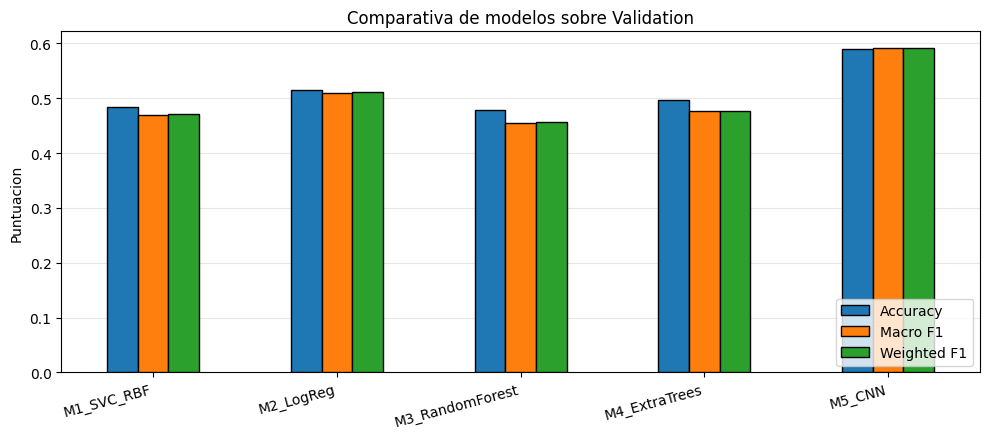

,Representacion,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Modelo,,,,,,
M1_SVC_RBF,"Prosodia y dinamica temporal (40d, waveform)",0.484238,0.478119,0.484257,0.470161,0.471451
M2_LogReg,MFCC+delta+delta2 mean+std (120d),0.515762,0.515528,0.514596,0.509457,0.511353
M3_RandomForest,MFCC + Espectrales (27d),0.478109,0.495072,0.477988,0.455417,0.457065
M4_ExtraTrees,Todas las caracteristicas (127d),0.497373,0.501709,0.498081,0.476784,0.477494
M5_CNN,Log-mel 64x94,0.589317,0.623555,0.587824,0.592427,0.591864


In [36]:
# ---- Tabla comparativa (sobre VALIDATION) ----
REPRESENTACIONES = {
    1: ('M1_SVC_RBF',      'Prosodia y dinamica temporal (40d, waveform)'),
    2: ('M2_LogReg',       'MFCC+delta+delta2 mean+std (120d)'),
    3: ('M3_RandomForest', 'MFCC + Espectrales (27d)'),
    4: ('M4_ExtraTrees',   'Todas las caracteristicas (127d)'),
    5: ('M5_CNN',          'Log-mel 64x94'),
}

probs = pd.read_csv(RUTA_PROBS).sort_values('sample_id').reset_index(drop=True)
y_true = probs['true_label'].values

filas = []
for num in sorted(REPRESENTACIONES):
    cols = [f'prob_model_{num}_{NOMBRES[c]}' for c in CLASSES]
    if not all(c in probs.columns for c in cols):
        print(f'Modelo {num}: aun no esta en el CSV, se omite')
        continue
    P = probs[cols].values
    nombre, repr_ = REPRESENTACIONES[num]
    filas.append(evaluar(y_true, pred_desde_probs(P), nombre, repr_))

tabla = pd.DataFrame(filas).set_index('Modelo')
tabla.reset_index().to_csv(os.path.join(RUTA_CSV, 'model_results.csv'), index=False)
tabla_fmt = tabla.copy()
for c in tabla_fmt.columns[1:]:
    tabla_fmt[c] = tabla_fmt[c].map('{:.4f}'.format)

print('Metricas sobre VALIDATION (1142 audios, 14 actores no vistos en train)\n')
print(tabla_fmt.to_string())

mejor = tabla['Macro F1'].idxmax()
print(f'\nMejor modelo: {mejor}  (Macro F1 = {tabla["Macro F1"].max():.4f})')

# ---- Grafico comparativo ----
ax = tabla[['Accuracy', 'Macro F1', 'Weighted F1']].plot(
    kind='bar', figsize=(10, 4.5), edgecolor='black', zorder=3)
ax.set_ylabel('Puntuacion')
ax.set_title('Comparativa de modelos sobre Validation')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

tabla

---
## 15. Probabilidades almacenadas y utilidades del ensemble

A partir de aqui **no se vuelve a entrenar ningun modelo**. Todos los analisis
(soft voting, Leave-One-Model-Out, las 26 combinaciones, correlacion y
diversidad) se hacen sobre las probabilidades ya guardadas, como exige el
enunciado.

- `validation_probabilities.csv` -> se usa para **todas** las decisiones.
- `test_probabilities.csv` -> solo se abre al final, una unica vez.

In [37]:
# ---- Carga de probabilidades y utilidades ----
IDX_CLASE = {c: i for i, c in enumerate(CLASSES)}


def cargar_probabilidades(ruta):
    """Devuelve (df, {num_modelo: matriz (N,6)}, etiquetas) ordenado por sample_id."""
    d = pd.read_csv(ruta).sort_values('sample_id').reset_index(drop=True)
    nums = sorted({int(c.split('_')[2]) for c in d.columns if c.startswith('prob_model_')})
    P = {}
    for m in nums:
        cols = [f'prob_model_{m}_{NOMBRES[c]}' for c in CLASSES]
        M = d[cols].values
        assert np.allclose(M.sum(axis=1), 1.0, atol=1e-5), f'M{m} no suma 1'
        P[m] = M
    return d, P, d['true_label'].values


def macro_f1_rapido(y_i, pred_i, n=6):
    """Macro F1 con bincount. Identico a sklearn pero ~100x mas rapido.

    Se usa dentro de las busquedas de pesos, donde hay ~10.600 evaluaciones:
    con f1_score de sklearn la busqueda pasaria de segundos a varios minutos.
    """
    cm = np.bincount(y_i * n + pred_i, minlength=n * n).reshape(n, n)
    tp = np.diag(cm).astype(float)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    return float(np.mean(2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)))


def _composiciones(total, k, minimo):
    """Reparte `total` unidades entre k modelos, con un minimo por modelo."""
    if k == 1:
        if total >= minimo:
            yield (total,)
        return
    for v in range(minimo, total - minimo * (k - 1) + 1):
        for resto in _composiciones(total - v, k - 1, minimo):
            yield (v,) + resto


PASO_PESOS, PESO_MINIMO = 0.05, 0.05


def optimizar_pesos(modelos, P, y_i, paso=PASO_PESOS, peso_min=PESO_MINIMO):
    """Grid search exhaustivo de pesos sobre VALIDATION.

    Recorre todas las combinaciones de pesos multiplos de `paso` que suman 1,
    con un minimo por modelo, y devuelve la de mayor Macro F1.
    """
    total, minimo = int(round(1 / paso)), int(round(peso_min / paso))
    pila = np.stack([P[m] for m in modelos])          # (k, N, 6)
    mejor_f1, mejor_w = -1.0, None
    for comp in _composiciones(total, len(modelos), minimo):
        w = np.asarray(comp, dtype=float) / total
        f1 = macro_f1_rapido(y_i, np.tensordot(w, pila, axes=1).argmax(1))
        if f1 > mejor_f1:
            mejor_f1, mejor_w = f1, w
    return mejor_w, mejor_f1


def probs_ensemble(modelos, pesos, P):
    return np.tensordot(np.asarray(pesos, float), np.stack([P[m] for m in modelos]), axes=1)


def evaluar_ensemble(modelos, pesos, P, y, nombre, repr_=''):
    return evaluar(y, pred_desde_probs(probs_ensemble(modelos, pesos, P)), nombre, repr_)


def fmt_pesos(modelos, pesos):
    return ', '.join(f'M{m}={w:.2f}' for m, w in zip(modelos, pesos))


# ---- Carga ----
df_val, P_val, y_val_ens = cargar_probabilidades(RUTA_PROBS)
y_val_i = np.array([IDX_CLASE[c] for c in y_val_ens])
MODELOS = sorted(P_val)
print(f'Validation: {df_val.shape} | modelos {MODELOS}')
n_pesos = sum(1 for _ in _composiciones(int(round(1/PASO_PESOS)), len(MODELOS),
                                        int(round(PESO_MINIMO/PASO_PESOS))))
print(f'Grid de pesos para {len(MODELOS)} modelos: {n_pesos} combinaciones '
      f'(paso {PASO_PESOS}, minimo {PESO_MINIMO})')

# Comprobacion de que macro_f1_rapido == sklearn
_p = pred_desde_probs(P_val[MODELOS[0]])
assert abs(macro_f1_rapido(y_val_i, P_val[MODELOS[0]].argmax(1))
           - f1_score(y_val_ens, _p, average='macro', labels=CLASSES, zero_division=0)) < 1e-12
print('macro_f1_rapido verificado contra sklearn')

Validation: (1142, 32) | modelos [1, 2, 3, 4, 5]
Grid de pesos para 5 modelos: 3876 combinaciones (paso 0.05, minimo 0.05)
macro_f1_rapido verificado contra sklearn


In [38]:
# ---- Ensamblar test_probabilities.csv desde los .npy de cada modelo ----
# Cada celda de persistencia guardo P_test_m{N}.npy. Aqui se juntan en un unico
# CSV con el mismo formato que el de validation. No se mira su contenido hasta
# la seccion 24.

def construir_probabilidades(indices, sufijo, destino):
    sid = df_caracteristicas.iloc[indices]['sample_id'].values
    out = pd.DataFrame({'sample_id': sid,
                        'true_label': df_caracteristicas.iloc[indices]['emocion'].values})
    faltan = []
    for m in range(1, 6):
        ruta = os.path.join(RUTA_CSV, f'P_{sufijo}_m{m}.npy')
        if not os.path.exists(ruta):
            faltan.append(m); continue
        P = np.load(ruta)
        assert P.shape == (len(sid), 6), f'M{m}: {P.shape} != {(len(sid), 6)}'
        assert np.allclose(P.sum(axis=1), 1.0, atol=1e-5), f'M{m} no suma 1'
        for j, c in enumerate(CLASSES):
            out[f'prob_model_{m}_{NOMBRES[c]}'] = P[:, j]
    if faltan:
        raise FileNotFoundError(f'Faltan P_{sufijo}_m*.npy de los modelos {faltan}. '
                                f'Ejecuta primero sus celdas de persistencia.')
    out = out.sort_values('sample_id').reset_index(drop=True)
    assert out.isna().sum().sum() == 0
    out.to_csv(destino, index=False)
    print(f'{sufijo}: {out.shape} -> {os.path.basename(destino)}')
    return out


construir_probabilidades(idx_test, 'test', RUTA_PROBS_TEST)

test: (1148, 32) -> test_probabilities.csv


,sample_id,true_label,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad,prob_model_3_anger,prob_model_3_disgust,prob_model_3_fear,prob_model_3_happy,prob_model_3_neutral,prob_model_3_sad,prob_model_4_anger,prob_model_4_disgust,prob_model_4_fear,prob_model_4_happy,prob_model_4_neutral,prob_model_4_sad,prob_model_5_anger,prob_model_5_disgust,prob_model_5_fear,prob_model_5_happy,prob_model_5_neutral,prob_model_5_sad
0,1001_DFA_ANG_XX.wav,ANG,0.890632,0.018011,0.010181,0.073700,0.005912,0.001565,0.781040,0.005669,0.005144,0.199797,0.008187,0.000164,0.374668,0.125894,0.086949,0.355346,0.033810,0.023333,0.576,0.136,0.066,0.160,0.046,0.016,0.867580,0.066065,0.003161,0.059590,0.001821,0.001783
1,1001_DFA_DIS_XX.wav,DIS,0.103894,0.158174,0.041153,0.608113,0.068526,0.020140,0.006551,0.012681,0.137141,0.768800,0.068688,0.006140,0.086944,0.269289,0.117611,0.390944,0.088144,0.047067,0.200,0.166,0.110,0.280,0.198,0.046,0.065916,0.613996,0.073281,0.133229,0.028978,0.084600
2,1001_DFA_FEA_XX.wav,FEA,0.314823,0.054849,0.354552,0.267089,0.003619,0.005067,0.020158,0.004334,0.076296,0.871476,0.027649,0.000088,0.315754,0.130265,0.163603,0.346914,0.036667,0.006797,0.322,0.146,0.148,0.264,0.098,0.022,0.411623,0.054906,0.122093,0.394744,0.007515,0.009117
3,1001_DFA_HAP_XX.wav,HAP,0.705910,0.080354,0.020017,0.189298,0.003227,0.001194,0.035487,0.001587,0.019858,0.934547,0.008491,0.000030,0.385720,0.097230,0.107593,0.332791,0.006667,0.070000,0.520,0.106,0.064,0.236,0.046,0.028,0.066173,0.003476,0.069286,0.857947,0.001932,0.001187
4,1001_DFA_NEU_XX.wav,NEU,0.181434,0.112683,0.063476,0.468844,0.157445,0.016118,0.025488,0.003286,0.003387,0.664503,0.302006,0.001330,0.232123,0.144889,0.080160,0.405325,0.124085,0.013419,0.234,0.176,0.044,0.382,0.132,0.032,0.007802,0.001286,0.011092,0.905741,0.070346,0.003733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,1078_WSI_DIS_XX.wav,DIS,0.519396,0.071393,0.098614,0.284796,0.010710,0.015090,0.655779,0.262256,0.001395,0.076903,0.003297,0.000371,0.298456,0.307221,0.044768,0.281396,0.047826,0.020333,0.520,0.120,0.048,0.244,0.050,0.018,0.111104,0.042445,0.015512,0.816601,0.011293,0.003045
1144,1078_WSI_FEA_XX.wav,FEA,0.162150,0.051666,0.517383,0.215834,0.016448,0.036519,0.072906,0.067861,0.510373,0.346782,0.000296,0.001783,0.331155,0.087276,0.320175,0.237916,0.016812,0.006667,0.406,0.072,0.202,0.296,0.022,0.002,0.007350,0.001993,0.607640,0.379677,0.000688,0.002652
1145,1078_WSI_HAP_XX.wav,HAP,0.316998,0.030904,0.101194,0.536812,0.009052,0.005040,0.028632,0.045676,0.127601,0.782289,0.002462,0.013340,0.442912,0.105785,0.024971,0.359551,0.043448,0.023333,0.324,0.064,0.178,0.412,0.008,0.014,0.022652,0.010213,0.134266,0.820617,0.006380,0.005872
1146,1078_WSI_NEU_XX.wav,NEU,0.029455,0.090048,0.117384,0.075150,0.448161,0.239802,0.001931,0.053447,0.028641,0.102116,0.452989,0.360876,0.021985,0.227561,0.117576,0.076479,0.402486,0.153914,0.020,0.250,0.128,0.104,0.272,0.226,0.005084,0.053477,0.049166,0.012548,0.519123,0.360602


---
## 16. Uniform Soft Voting

Todos los modelos pesan igual:

$$P_{ensemble}(c) = \frac{1}{M}\sum_{m=1}^{M} P_m(c), \qquad
\hat{y} = \arg\max_c P_{ensemble}(c)$$

In [39]:
# ---- Uniform Soft Voting (pesos iguales) ----
pesos_uniforme = np.full(len(MODELOS), 1 / len(MODELOS))
res_uniforme = evaluar_ensemble(MODELOS, pesos_uniforme, P_val, y_val_ens,
                                'Uniform_Soft_Voting',
                                f'M{"+M".join(map(str, MODELOS))} (peso {1/len(MODELOS):.2f} c/u)')
print(pd.Series(res_uniforme).to_string())

pd.DataFrame([res_uniforme]).to_csv(os.path.join(RUTA_CSV, 'uniform_soft_voting.csv'), index=False)

mejor_individual = max(MODELOS, key=lambda m: f1_score(
    y_val_ens, pred_desde_probs(P_val[m]), average='macro', labels=CLASSES, zero_division=0))
f1_mejor_ind = f1_score(y_val_ens, pred_desde_probs(P_val[mejor_individual]),
                        average='macro', labels=CLASSES, zero_division=0)
print(f'\nMejor modelo individual: M{mejor_individual} (Macro F1 {f1_mejor_ind:.4f})')
print(f'Uniform Soft Voting    : {res_uniforme["Macro F1"]:.4f}  '
      f'({res_uniforme["Macro F1"]-f1_mejor_ind:+.4f})')

Modelo                        Uniform_Soft_Voting
Representacion     M1+M2+M3+M4+M5 (peso 0.20 c/u)
Accuracy                                 0.593695
Macro Precision                          0.604342
Macro Recall                             0.593244
Macro F1                                 0.586378
Weighted F1                               0.58695

Mejor modelo individual: M5 (Macro F1 0.5924)
Uniform Soft Voting    : 0.5864  (-0.0060)


---
## 17. Weighted Soft Voting

$$P_{ensemble}(c) = \sum_{m=1}^{M} w_m P_m(c), \qquad \sum_{m=1}^{M} w_m = 1$$

**Procedimiento para encontrar los pesos:** grid search exhaustivo en pasos de
0.05, con un peso minimo de 0.05 por modelo para que todos participen, quedandose
con la combinacion de mayor Macro F1 **sobre Validation**.

Es exhaustivo, no heuristico: recorre todas las reparticiones posibles, asi que
el optimo encontrado es el optimo global dentro de esa rejilla. Test no
interviene en ningun momento.

Busqueda terminada en 0.9s
Pesos optimos: M1=0.05, M2=0.20, M3=0.05, M4=0.35, M5=0.35  ->  Macro F1 0.6171

Modelo                                    Weighted_Soft_Voting
Representacion     M1=0.05, M2=0.20, M3=0.05, M4=0.35, M5=0.35
Accuracy                                              0.618214
Macro Precision                                       0.631315
Macro Recall                                          0.618036
Macro F1                                              0.617083
Weighted F1                                            0.61687


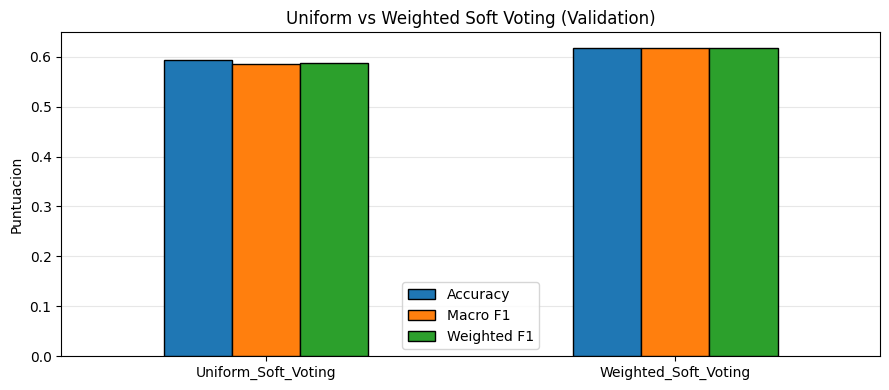

,Accuracy,Macro F1,Weighted F1
Modelo,,,
Uniform_Soft_Voting,0.593695,0.586378,0.58695
Weighted_Soft_Voting,0.618214,0.617083,0.61687


In [40]:
# ---- Weighted Soft Voting: busqueda de pesos sobre VALIDATION ----
t0 = time.time()
pesos_opt, f1_opt = optimizar_pesos(MODELOS, P_val, y_val_i)
print(f'Busqueda terminada en {time.time()-t0:.1f}s')
print(f'Pesos optimos: {fmt_pesos(MODELOS, pesos_opt)}  ->  Macro F1 {f1_opt:.4f}')

res_weighted = evaluar_ensemble(MODELOS, pesos_opt, P_val, y_val_ens,
                                'Weighted_Soft_Voting', fmt_pesos(MODELOS, pesos_opt))
print()
print(pd.Series(res_weighted).to_string())

fila = {'modelos': 'M' + '+M'.join(map(str, MODELOS))}
fila.update({f'peso_M{m}': w for m, w in zip(MODELOS, pesos_opt)})
fila.update({k: v for k, v in res_weighted.items() if k not in ('Modelo', 'Representacion')})
pd.DataFrame([fila]).to_csv(os.path.join(RUTA_CSV, 'weighted_soft_voting.csv'), index=False)

# ---- Uniform vs Weighted ----
comp = pd.DataFrame([res_uniforme, res_weighted]).set_index('Modelo')
ax = comp[['Accuracy', 'Macro F1', 'Weighted F1']].plot(
    kind='bar', figsize=(9, 4), edgecolor='black', zorder=3)
ax.set_title('Uniform vs Weighted Soft Voting (Validation)')
ax.set_ylabel('Puntuacion'); ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
comp[['Accuracy', 'Macro F1', 'Weighted F1']]

---
## 18. Leave-One-Model-Out

Se quita un modelo cada vez y se **vuelven a optimizar los pesos** de los que
quedan, de nuevo solo con Validation. Reoptimizar es importante: si se
reutilizaran los pesos del ensemble completo, la caida medida mezclaria el
efecto de quitar el modelo con el de usar pesos mal ajustados.

configuracion        modelos                                       pesos  Accuracy  Macro F1  Weighted F1  Delta Macro F1
        Todos M1+M2+M3+M4+M5 M1=0.05, M2=0.20, M3=0.05, M4=0.35, M5=0.35  0.618214  0.617083     0.616870        0.000000
       Sin M1    M2+M3+M4+M5          M2=0.05, M3=0.15, M4=0.50, M5=0.30  0.620841  0.617615     0.617225        0.000532
       Sin M2    M1+M3+M4+M5          M1=0.05, M3=0.05, M4=0.60, M5=0.30  0.619089  0.616773     0.616265       -0.000310
       Sin M3    M1+M2+M4+M5          M1=0.10, M2=0.10, M4=0.50, M5=0.30  0.622592  0.619838     0.619573        0.002755
       Sin M4    M1+M2+M3+M5          M1=0.30, M2=0.15, M3=0.10, M5=0.45  0.615587  0.615775     0.616098       -0.001308
       Sin M5    M1+M2+M3+M4          M1=0.25, M2=0.50, M3=0.05, M4=0.20  0.536778  0.528825     0.530722       -0.088258

Quitar Sin M5 es lo que mas dana -> es el modelo que mas aporta.
Sin M3 MEJORA el ensemble (+0.0028): ese modelo esta restando.


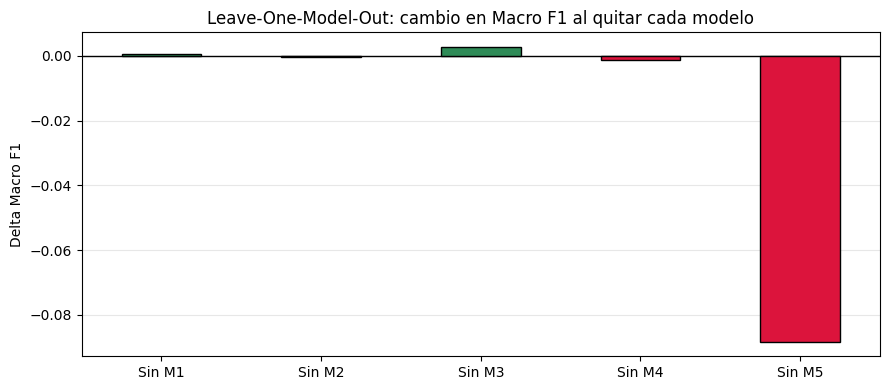

In [41]:
# ---- Leave-One-Model-Out ----
filas_lomo = []
pesos_todos, f1_todos = pesos_opt, f1_opt
filas_lomo.append({'configuracion': 'Todos', 'n_modelos': len(MODELOS),
                   'modelos': 'M' + '+M'.join(map(str, MODELOS)),
                   'pesos': fmt_pesos(MODELOS, pesos_todos),
                   **{k: v for k, v in res_weighted.items() if k not in ('Modelo', 'Representacion')},
                   'Delta Macro F1': 0.0})

for fuera in MODELOS:
    resto = [m for m in MODELOS if m != fuera]
    w, _ = optimizar_pesos(resto, P_val, y_val_i)
    r = evaluar_ensemble(resto, w, P_val, y_val_ens, f'Sin M{fuera}')
    filas_lomo.append({'configuracion': f'Sin M{fuera}', 'n_modelos': len(resto),
                       'modelos': 'M' + '+M'.join(map(str, resto)),
                       'pesos': fmt_pesos(resto, w),
                       **{k: v for k, v in r.items() if k not in ('Modelo', 'Representacion')},
                       'Delta Macro F1': r['Macro F1'] - f1_todos})

lomo = pd.DataFrame(filas_lomo)
lomo.to_csv(os.path.join(RUTA_CSV, 'leave_one_model_out.csv'), index=False)
print(lomo[['configuracion', 'modelos', 'pesos', 'Accuracy', 'Macro F1',
            'Weighted F1', 'Delta Macro F1']].to_string(index=False))

# Delta > 0 significa que el ensemble MEJORA al quitar ese modelo
sub = lomo[lomo.configuracion != 'Todos']
ax = sub.plot(x='configuracion', y='Delta Macro F1', kind='bar', figsize=(9, 4),
              color=['crimson' if v < 0 else 'seagreen' for v in sub['Delta Macro F1']],
              edgecolor='black', legend=False, zorder=3)
ax.axhline(0, color='black', lw=1)
ax.set_title('Leave-One-Model-Out: cambio en Macro F1 al quitar cada modelo')
ax.set_ylabel('Delta Macro F1'); ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

peor = sub.loc[sub['Delta Macro F1'].idxmin(), 'configuracion']
mejor_quitar = sub.loc[sub['Delta Macro F1'].idxmax()]
print(f'\nQuitar {peor} es lo que mas dana -> es el modelo que mas aporta.')
if mejor_quitar['Delta Macro F1'] > 0:
    print(f'{mejor_quitar["configuracion"]} MEJORA el ensemble '
          f'({mejor_quitar["Delta Macro F1"]:+.4f}): ese modelo esta restando.')

---
## 19. Las 26 combinaciones posibles

$$\binom{5}{2}+\binom{5}{3}+\binom{5}{4}+\binom{5}{5} = 10+10+5+1 = 26$$

Se generan automaticamente con `itertools.combinations` y para **cada una** se
reoptimizan los pesos sobre Validation.

26 combinaciones evaluadas en 2.2s

 n_modelos        modelos                                       pesos  Accuracy  Macro F1
         4    M1+M2+M4+M5          M1=0.10, M2=0.10, M4=0.50, M5=0.30  0.622592  0.619838
         4    M2+M3+M4+M5          M2=0.05, M3=0.15, M4=0.50, M5=0.30  0.620841  0.617615
         5 M1+M2+M3+M4+M5 M1=0.05, M2=0.20, M3=0.05, M4=0.35, M5=0.35  0.618214  0.617083
         4    M1+M3+M4+M5          M1=0.05, M3=0.05, M4=0.60, M5=0.30  0.619089  0.616773
         3       M1+M2+M5                   M1=0.35, M2=0.25, M5=0.40  0.616462  0.615900
         4    M1+M2+M3+M5          M1=0.30, M2=0.15, M3=0.10, M5=0.45  0.615587  0.615775
         3       M2+M4+M5                   M2=0.10, M4=0.60, M5=0.30  0.617338  0.614819
         3       M3+M4+M5                   M3=0.20, M4=0.50, M5=0.30  0.617338  0.614278
         2          M4+M5                            M4=0.70, M5=0.30  0.615587  0.613745
         3       M1+M4+M5                   M1=0.05, M4=0.65, M5

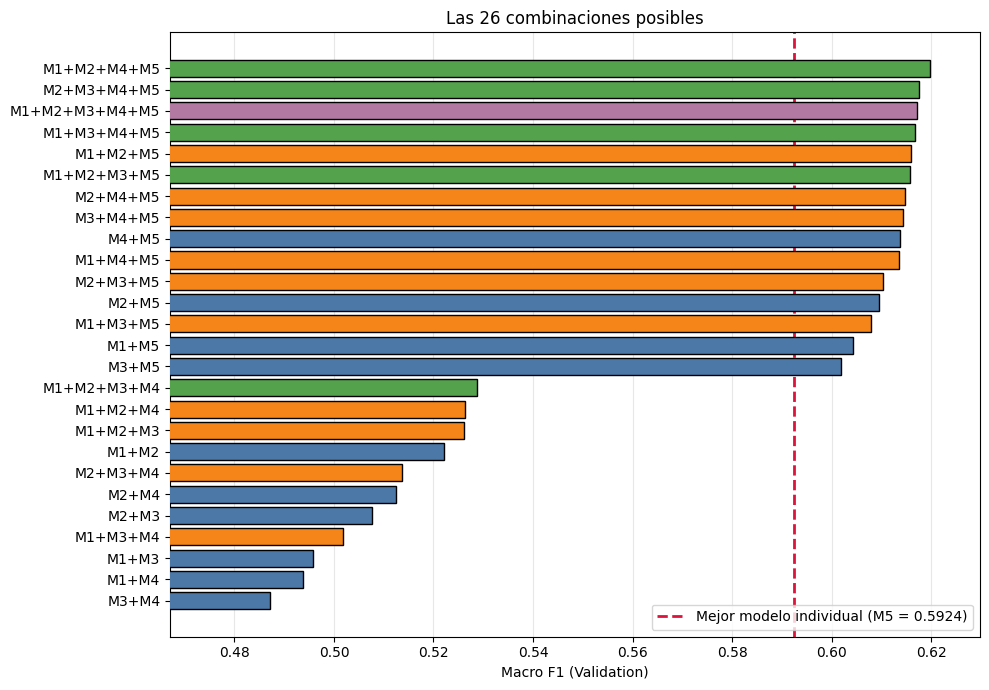

In [42]:
# ---- Las 26 combinaciones de 2 a 5 modelos ----
filas_comb = []
t0 = time.time()
for r in range(2, len(MODELOS) + 1):
    for combo in itertools.combinations(MODELOS, r):
        combo = list(combo)
        w, _ = optimizar_pesos(combo, P_val, y_val_i)
        met = evaluar_ensemble(combo, w, P_val, y_val_ens, 'M' + '+M'.join(map(str, combo)))
        filas_comb.append({'n_modelos': r, 'modelos': 'M' + '+M'.join(map(str, combo)),
                           'pesos': fmt_pesos(combo, w),
                           **{k: v for k, v in met.items() if k not in ('Modelo', 'Representacion')}})

combinaciones = pd.DataFrame(filas_comb).sort_values('Macro F1', ascending=False).reset_index(drop=True)
combinaciones.to_csv(os.path.join(RUTA_CSV, 'all_model_combinations.csv'), index=False)

print(f'{len(combinaciones)} combinaciones evaluadas en {time.time()-t0:.1f}s')
assert len(combinaciones) == 26, 'deben ser exactamente 26'
print()
print(combinaciones.head(10)[['n_modelos', 'modelos', 'pesos', 'Accuracy', 'Macro F1']].to_string(index=False))

colores = {2: '#4C78A8', 3: '#F58518', 4: '#54A24B', 5: '#B279A2'}
orden = combinaciones.sort_values('Macro F1')
plt.figure(figsize=(10, 7))
plt.barh(orden['modelos'], orden['Macro F1'],
         color=[colores[n] for n in orden['n_modelos']], edgecolor='black', zorder=3)
plt.axvline(f1_mejor_ind, color='crimson', ls='--', lw=2,
            label=f'Mejor modelo individual (M{mejor_individual} = {f1_mejor_ind:.4f})')
plt.xlabel('Macro F1 (Validation)'); plt.title('Las 26 combinaciones posibles')
plt.xlim(orden['Macro F1'].min() - 0.02, orden['Macro F1'].max() + 0.01)
plt.legend(loc='lower right'); plt.grid(axis='x', alpha=0.3, zorder=0)
plt.tight_layout(); plt.show()

---
## 20. Mejor combinacion por numero de modelos

La pregunta del enunciado: **¿hacen falta de verdad los cinco modelos?**

In [43]:
# ---- Mejor combinacion de cada tamano ----
filas_tam = []
for r in range(2, len(MODELOS) + 1):
    sub = combinaciones[combinaciones.n_modelos == r]
    b = sub.loc[sub['Macro F1'].idxmax()]
    filas_tam.append({'etiqueta': f'Mejor de {r} modelos', **b.to_dict()})
cinco = combinaciones[combinaciones.n_modelos == len(MODELOS)].iloc[0]
filas_tam.append({'etiqueta': f'Los {len(MODELOS)} modelos', **cinco.to_dict()})
glob_ = combinaciones.iloc[0]
filas_tam.append({'etiqueta': 'Mejor ensemble global', **glob_.to_dict()})

mejores = pd.DataFrame(filas_tam)
mejores.to_csv(os.path.join(RUTA_CSV, 'best_combination_by_size.csv'), index=False)
print(mejores[['etiqueta', 'modelos', 'pesos', 'Accuracy', 'Macro F1', 'Weighted F1']].to_string(index=False))

print(f'\nMejor individual      : M{mejor_individual}  {f1_mejor_ind:.4f}')
print(f'Mejor ensemble global : {glob_["modelos"]}  {glob_["Macro F1"]:.4f}  '
      f'({glob_["Macro F1"]-f1_mejor_ind:+.4f} frente al mejor individual)')

             etiqueta        modelos                                       pesos  Accuracy  Macro F1  Weighted F1
   Mejor de 2 modelos          M4+M5                            M4=0.70, M5=0.30  0.615587  0.613745     0.613479
   Mejor de 3 modelos       M1+M2+M5                   M1=0.35, M2=0.25, M5=0.40  0.616462  0.615900     0.616605
   Mejor de 4 modelos    M1+M2+M4+M5          M1=0.10, M2=0.10, M4=0.50, M5=0.30  0.622592  0.619838     0.619573
   Mejor de 5 modelos M1+M2+M3+M4+M5 M1=0.05, M2=0.20, M3=0.05, M4=0.35, M5=0.35  0.618214  0.617083     0.616870
        Los 5 modelos M1+M2+M3+M4+M5 M1=0.05, M2=0.20, M3=0.05, M4=0.35, M5=0.35  0.618214  0.617083     0.616870
Mejor ensemble global    M1+M2+M4+M5          M1=0.10, M2=0.10, M4=0.50, M5=0.30  0.622592  0.619838     0.619573

Mejor individual      : M5  0.5924
Mejor ensemble global : M1+M2+M4+M5  0.6198  (+0.0274 frente al mejor individual)


---
## 21. Correlacion entre las probabilidades de los modelos

Se aplana la matriz (N x 6) de cada modelo y se correlaciona con la de los demas.
Dos modelos con correlacion alta producen distribuciones de probabilidad casi
iguales y, por tanto, aportan poco el uno al otro dentro del ensemble.

       M1     M2     M3     M4     M5
M1  1.000  0.654  0.754  0.784  0.589
M2  0.654  1.000  0.701  0.783  0.606
M3  0.754  0.701  1.000  0.875  0.594
M4  0.784  0.783  0.875  1.000  0.626
M5  0.589  0.606  0.594  0.626  1.000
Par MAS correlacionado : M3-M4  0.875
Par MENOS correlacionado: M1-M5  0.589


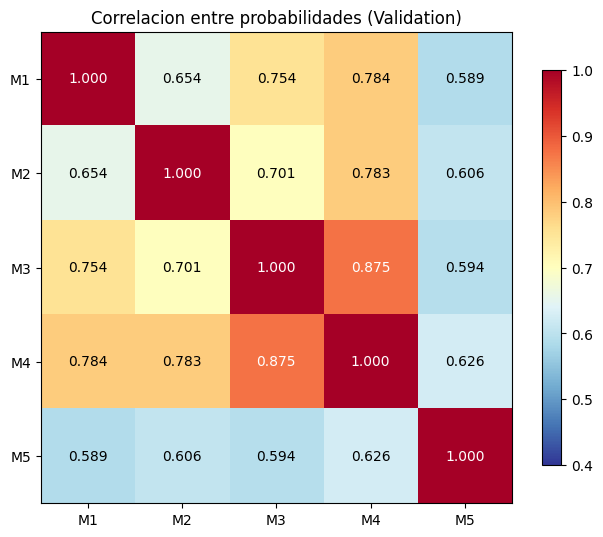

In [44]:
# ---- Matriz de correlacion de probabilidades ----
etiquetas = [f'M{m}' for m in MODELOS]
corr = pd.DataFrame(np.corrcoef([P_val[m].ravel() for m in MODELOS]),
                    index=etiquetas, columns=etiquetas)
corr.to_csv(os.path.join(RUTA_CSV, 'probability_correlation.csv'))
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap='RdYlBu_r', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(etiquetas))); ax.set_xticklabels(etiquetas)
ax.set_yticks(range(len(etiquetas))); ax.set_yticklabels(etiquetas)
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                color='white' if v > 0.85 else 'black', fontsize=10)
ax.set_title('Correlacion entre probabilidades (Validation)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

fuera_diag = corr.where(~np.eye(len(corr), dtype=bool))
par_max = fuera_diag.stack().idxmax(); par_min = fuera_diag.stack().idxmin()
print(f'Par MAS correlacionado : {par_max[0]}-{par_max[1]}  {fuera_diag.stack().max():.3f}')
print(f'Par MENOS correlacionado: {par_min[0]}-{par_min[1]}  {fuera_diag.stack().min():.3f}')

---
## 22. Diversidad de errores

La correlacion no basta: dos modelos pueden dar probabilidades parecidas y aun
asi acertar en audios distintos. Para cada par se cuenta la tabla 2x2:

| | B acierta | B falla |
|---|---|---|
| **A acierta** | ambos aciertan | solo A acierta |
| **A falla** | solo B acierta | ambos fallan |

El **desacuerdo** es el porcentaje de audios donde predicen etiquetas distintas.
Lo interesante para el ensemble son las casillas *solo A* y *solo B*: ahi es donde
un modelo puede corregir al otro.

  par  ambos_aciertan  solo_A_acierta  solo_B_acierta  ambos_fallan  desacuerdo_%  jaccard_errores_%  complementariedad_%  correlacion
M3-M5             408             138             265           331         49.30              45.10                35.29        0.594
M2-M5             435             154             238           315         47.02              44.55                34.33        0.606
M1-M5             423             130             250           339         48.51              47.15                33.27        0.589
M4-M5             432             136             241           333         46.67              46.90                33.01        0.626
M1-M2             394             159             195           394         47.72              52.67                31.00        0.654
M2-M3             394             195             152           401         45.62              53.61                30.39        0.701
M2-M4             441             148             127  

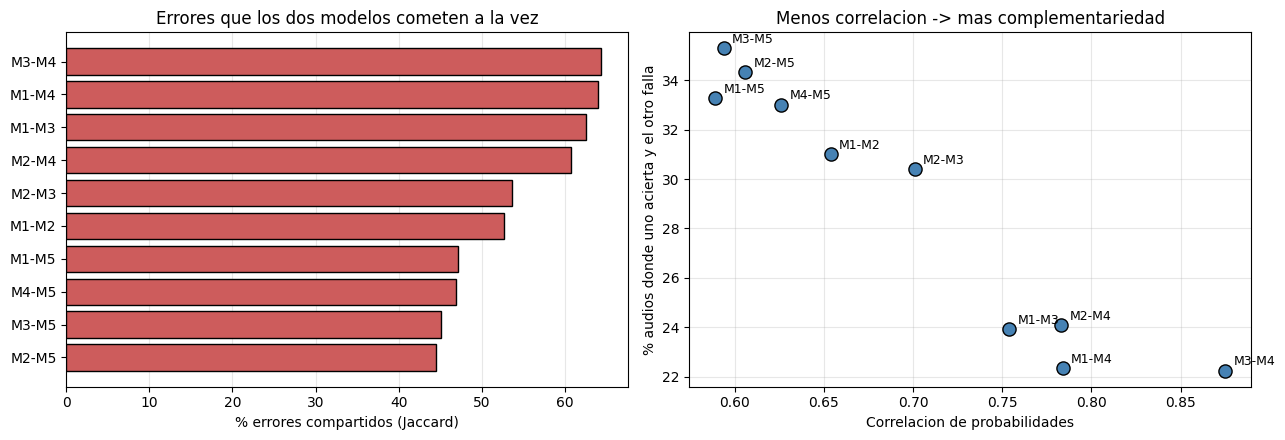

In [45]:
# ---- Diversidad de errores por pares ----
preds = {m: pred_desde_probs(P_val[m]) for m in MODELOS}
acierta = {m: preds[m] == y_val_ens for m in MODELOS}

filas_div = []
for a, b in itertools.combinations(MODELOS, 2):
    aa, bb = acierta[a], acierta[b]
    n = len(aa)
    filas_div.append({
        'par': f'M{a}-M{b}',
        'ambos_aciertan': int((aa & bb).sum()),
        f'solo_A_acierta': int((aa & ~bb).sum()),
        f'solo_B_acierta': int((~aa & bb).sum()),
        'ambos_fallan': int((~aa & ~bb).sum()),
        'desacuerdo_%': round(100 * (preds[a] != preds[b]).mean(), 2),
        'jaccard_errores_%': round(100 * ((~aa & ~bb).sum() / max(1, (~aa | ~bb).sum())), 2),
        'complementariedad_%': round(100 * ((aa ^ bb).sum() / n), 2),
        'correlacion': round(float(np.corrcoef(P_val[a].ravel(), P_val[b].ravel())[0, 1]), 3),
    })

diversidad = pd.DataFrame(filas_div).sort_values('complementariedad_%', ascending=False)
diversidad.to_csv(os.path.join(RUTA_CSV, 'error_diversity.csv'), index=False)
print(diversidad.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
d = diversidad.sort_values('jaccard_errores_%')
ax[0].barh(d['par'], d['jaccard_errores_%'], color='indianred', edgecolor='black', zorder=3)
ax[0].set_xlabel('% errores compartidos (Jaccard)')
ax[0].set_title('Errores que los dos modelos cometen a la vez')
ax[0].grid(axis='x', alpha=0.3, zorder=0)
ax[1].scatter(diversidad['correlacion'], diversidad['complementariedad_%'],
              s=90, color='steelblue', edgecolor='black', zorder=3)
for _, r in diversidad.iterrows():
    ax[1].annotate(r['par'], (r['correlacion'], r['complementariedad_%']),
                   textcoords='offset points', xytext=(6, 4), fontsize=9)
ax[1].set_xlabel('Correlacion de probabilidades')
ax[1].set_ylabel('% audios donde uno acierta y el otro falla')
ax[1].set_title('Menos correlacion -> mas complementariedad')
ax[1].grid(alpha=0.3, zorder=0)
plt.tight_layout(); plt.show()

mejor_par = diversidad.iloc[0]
print(f"\nPar mas complementario: {mejor_par['par']} "
      f"({mejor_par['complementariedad_%']}% de audios donde uno salva al otro)")

---
## 23. Seleccion del ensemble final

**Criterio:** mayor Macro F1 en Validation. Si varias combinaciones quedan dentro
de una tolerancia de 0.005 (diferencia sin significado practico con 1142
muestras), se elige la que usa **menos modelos**: mismo rendimiento con menos
piezas es un sistema mas simple de justificar y de ejecutar.

A partir de esta celda quedan **congelados** los modelos, los pesos y los
hiperparametros. Nada de lo que venga despues puede modificarlos.

In [46]:
# ---- Seleccion y congelado ----
TOLERANCIA = 0.005
tope = combinaciones['Macro F1'].max()
candidatas = combinaciones[combinaciones['Macro F1'] >= tope - TOLERANCIA]
elegida = candidatas.sort_values(['n_modelos', 'Macro F1'],
                                 ascending=[True, False]).iloc[0]

print(f'Mejor Macro F1 en Validation: {tope:.4f}')
print(f'Dentro de la tolerancia ({TOLERANCIA}): {len(candidatas)} combinaciones')
print(candidatas[['n_modelos', 'modelos', 'Macro F1']].to_string(index=False))

MODELOS_FINAL = [int(x[1:]) for x in elegida['modelos'].split('+')]
PESOS_FINAL = np.array([float(p.split('=')[1]) for p in elegida['pesos'].split(', ')])
assert abs(PESOS_FINAL.sum() - 1) < 1e-9
print(f'\n>>> ENSEMBLE FINAL: {elegida["modelos"]}  |  {elegida["pesos"]}')
print(f'    Macro F1 en Validation = {elegida["Macro F1"]:.4f}')

ensemble_final = {
    'modelos': MODELOS_FINAL,
    'pesos': {f'M{m}': float(w) for m, w in zip(MODELOS_FINAL, PESOS_FINAL)},
    'criterio': f'Mayor Macro F1 en Validation con tolerancia {TOLERANCIA}; '
                f'entre empatados, menos modelos',
    'busqueda_pesos': {'metodo': 'grid search exhaustivo', 'paso': PASO_PESOS,
                       'peso_minimo': PESO_MINIMO},
    'metricas_validation': {k: round(float(elegida[k]), 4) for k in
                            ['Accuracy', 'Macro Precision', 'Macro Recall',
                             'Macro F1', 'Weighted F1']},
    'representaciones': {
        'M1': 'Prosodia y dinamica temporal (40d, waveform)',
        'M2': 'MFCC + delta + delta2 mean+std (120d)',
        'M3': 'MFCC mean + descriptores espectrales (27d)',
        'M4': 'Todas las caracteristicas tabulares (127d)',
        'M5': 'Espectrograma log-mel 64x94 (CNN)',
    },
    'archivos_modelos': {
        '1': 'modelo_m1_svc.pkl', '2': 'modelo_m2_logreg.pkl',
        '3': 'modelo_m3_rf.pkl', '4': 'modelo_m4_extratrees_compress.pkl',
        '5': 'modelo_m5_cnn.pt',
    },
}
with open(os.path.join(RUTA_MODELOS, 'ensemble_final.json'), 'w', encoding='utf-8') as f:
    json.dump(ensemble_final, f, indent=4, ensure_ascii=False)
print(f'\nConfiguracion congelada en {RUTA_MODELOS}/ensemble_final.json')

Mejor Macro F1 en Validation: 0.6198
Dentro de la tolerancia (0.005): 6 combinaciones
 n_modelos        modelos  Macro F1
         4    M1+M2+M4+M5  0.619838
         4    M2+M3+M4+M5  0.617615
         5 M1+M2+M3+M4+M5  0.617083
         4    M1+M3+M4+M5  0.616773
         3       M1+M2+M5  0.615900
         4    M1+M2+M3+M5  0.615775

>>> ENSEMBLE FINAL: M1+M2+M5  |  M1=0.35, M2=0.25, M5=0.40
    Macro F1 en Validation = 0.6159

Configuracion congelada en ../Modelo-Entrenado/ensemble_final.json


---
## 24. Evaluacion final sobre Test

**Primera y unica vez que se abre Test.** Todo lo anterior se decidio con
Validation. Los modelos de referencia se muestran solo como contexto: no se usan
para cambiar ninguna decision, porque la configuracion ya quedo congelada.

Test: (1148, 32) | modelos [1, 2, 3, 4, 5]

         Tipo              Modelo  Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1
SISTEMA FINAL      ENSEMBLE_FINAL  0.569686         0.585473      0.568027  0.571902     0.571321
   Referencia                  M1  0.443380         0.435100      0.444728  0.430345     0.429067
   Referencia                  M2  0.461672         0.459739      0.460459  0.458250     0.458499
   Referencia                  M3  0.428571         0.423656      0.428571  0.413377     0.412975
   Referencia                  M4  0.446864         0.438567      0.447421  0.428466     0.427413
   Referencia                  M5  0.559233         0.609441      0.555556  0.561936     0.562426
   Referencia Uniform_Soft_Voting  0.532230         0.540265      0.531888  0.530504     0.529008

              precision    recall  f1-score   support

         ANG       0.67      0.68      0.68       196
         DIS       0.50      0.55      0.52       196
        

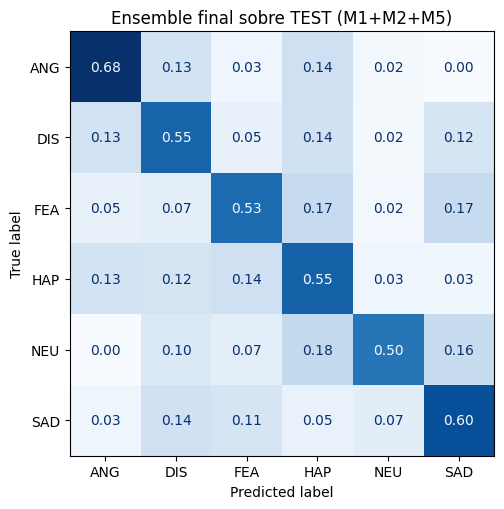

In [47]:
# ---- Evaluacion final sobre TEST ----
df_test, P_test, y_test_ens = cargar_probabilidades(RUTA_PROBS_TEST)
print(f'Test: {df_test.shape} | modelos {sorted(P_test)}')
assert set(P_test) >= set(MODELOS_FINAL), 'faltan modelos del ensemble en test'

res_final = evaluar_ensemble(MODELOS_FINAL, PESOS_FINAL, P_test, y_test_ens,
                             'ENSEMBLE_FINAL', 'M' + '+M'.join(map(str, MODELOS_FINAL)))

filas_test = [{'Tipo': 'SISTEMA FINAL', **res_final,
               'Pesos': fmt_pesos(MODELOS_FINAL, PESOS_FINAL)}]
for m in sorted(P_test):
    r = evaluar(y_test_ens, pred_desde_probs(P_test[m]), f'M{m}',
                ensemble_final['representaciones'][f'M{m}'])
    filas_test.append({'Tipo': 'Referencia', **r, 'Pesos': '-'})
r_unif = evaluar_ensemble(sorted(P_test), np.full(len(P_test), 1 / len(P_test)),
                          P_test, y_test_ens, 'Uniform_Soft_Voting', 'pesos iguales')
filas_test.append({'Tipo': 'Referencia', **r_unif, 'Pesos': f'{1/len(P_test):.2f} c/u'})

test_final = pd.DataFrame(filas_test)
test_final.to_csv(os.path.join(RUTA_CSV, 'final_test_results.csv'), index=False)
print()
print(test_final[['Tipo', 'Modelo', 'Accuracy', 'Macro Precision', 'Macro Recall',
                  'Macro F1', 'Weighted F1']].to_string(index=False))

pred_test_final = pred_desde_probs(probs_ensemble(MODELOS_FINAL, PESOS_FINAL, P_test))
cm_final = matriz_confusion(y_test_ens, pred_test_final,
                            f'Ensemble final sobre TEST ({elegida["modelos"]})')
print()
print(classification_report(y_test_ens, pred_test_final, labels=CLASSES, zero_division=0))

---
## 25. Comparacion final

Tabla unica con los cinco modelos individuales, los dos esquemas de voting y los
mejores ensembles por tamano, todo sobre **Validation** (que es donde se tomaron
las decisiones), mas la fila del sistema final sobre **Test**.

                            Sistema  Particion Accuracy Macro Precision Macro Recall Macro F1 Weighted F1
                           Modelo 1 Validation   0.4842          0.4781       0.4843   0.4702      0.4715
                           Modelo 2 Validation   0.5158          0.5155       0.5146   0.5095      0.5114
                           Modelo 3 Validation   0.4781          0.4951       0.4780   0.4554      0.4571
                           Modelo 4 Validation   0.4974          0.5017       0.4981   0.4768      0.4775
                           Modelo 5 Validation   0.5893          0.6236       0.5878   0.5924      0.5919
                Uniform Soft Voting Validation   0.5937          0.6043       0.5932   0.5864      0.5869
           Weighted Soft Voting (5) Validation   0.6182          0.6313       0.6180   0.6171      0.6169
         Mejor de 2 modelos (M4+M5) Validation   0.6156          0.6269       0.6150   0.6137      0.6135
      Mejor de 3 modelos (M1+M2+M5) Validation

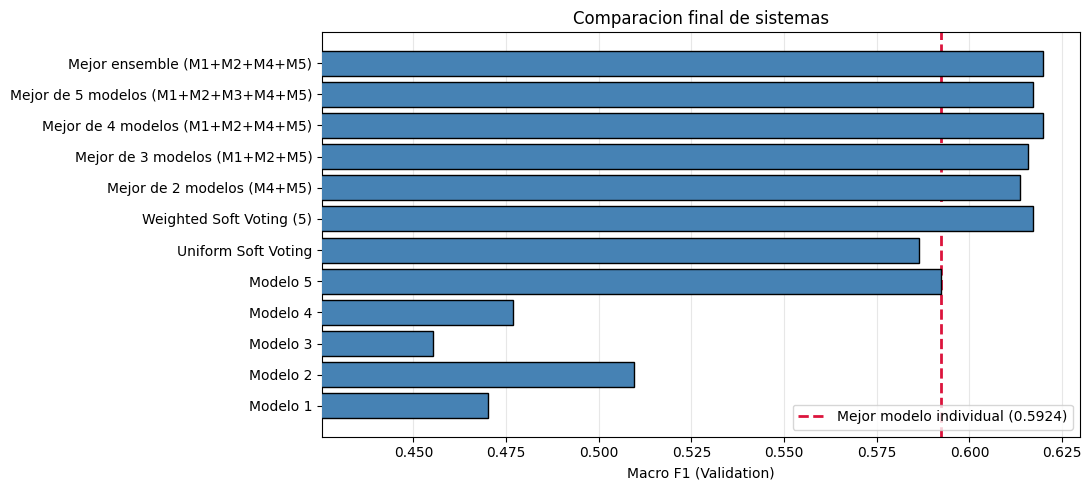

In [48]:
# ---- Tabla de comparacion final ----
METRICAS = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1']
filas_fin = []
for m in MODELOS:
    r = evaluar(y_val_ens, pred_desde_probs(P_val[m]), f'Modelo {m}',
                ensemble_final['representaciones'][f'M{m}'])
    filas_fin.append({'Sistema': f'Modelo {m}', 'Particion': 'Validation',
                      **{k: r[k] for k in METRICAS}})
for r, nom in [(res_uniforme, 'Uniform Soft Voting'), (res_weighted, 'Weighted Soft Voting (5)')]:
    filas_fin.append({'Sistema': nom, 'Particion': 'Validation', **{k: r[k] for k in METRICAS}})
for _, b in mejores[mejores.etiqueta.str.startswith('Mejor de')].iterrows():
    filas_fin.append({'Sistema': f'{b["etiqueta"]} ({b["modelos"]})', 'Particion': 'Validation',
                      **{k: b[k] for k in METRICAS}})
filas_fin.append({'Sistema': f'Mejor ensemble ({glob_["modelos"]})', 'Particion': 'Validation',
                  **{k: glob_[k] for k in METRICAS}})
filas_fin.append({'Sistema': f'SISTEMA FINAL ({elegida["modelos"]})', 'Particion': 'TEST',
                  **{k: res_final[k] for k in METRICAS}})

comparacion = pd.DataFrame(filas_fin)
comparacion.to_csv(os.path.join(RUTA_CSV, 'final_comparison.csv'), index=False)
print(comparacion.to_string(index=False,
      formatters={k: '{:.4f}'.format for k in METRICAS}))

val = comparacion[comparacion.Particion == 'Validation']
plt.figure(figsize=(11, 5))
plt.barh(val['Sistema'], val['Macro F1'], color='steelblue', edgecolor='black', zorder=3)
plt.axvline(f1_mejor_ind, color='crimson', ls='--', lw=2,
            label=f'Mejor modelo individual ({f1_mejor_ind:.4f})')
plt.xlabel('Macro F1 (Validation)'); plt.title('Comparacion final de sistemas')
plt.xlim(val['Macro F1'].min() - 0.03, val['Macro F1'].max() + 0.01)
plt.legend(loc='lower right'); plt.grid(axis='x', alpha=0.3, zorder=0)
plt.tight_layout(); plt.show()

---
## 26. Test with a New Audio

Carga un `.wav` cualquiera, le aplica **el preprocesamiento propio de cada
modelo** (cada uno espera una representacion distinta), ejecuta los cinco y
combina solo los del ensemble final con sus pesos congelados.

Cambia `AUDIO_PATH` por la ruta del audio que quieras probar.

In [49]:
# ---- Carga de los modelos entrenados desde disco ----
import warnings
from sklearn.exceptions import InconsistentVersionWarning
warnings.filterwarnings('ignore', category=InconsistentVersionWarning)

modelos_cargados = {
    1: joblib.load(os.path.join(RUTA_MODELOS, 'modelo_m1_svc.pkl')),
    2: joblib.load(os.path.join(RUTA_MODELOS, 'modelo_m2_logreg.pkl')),
    3: joblib.load(os.path.join(RUTA_MODELOS, 'modelo_m3_rf.pkl')),
    4: joblib.load(os.path.join(RUTA_MODELOS, 'modelo_m4_extratrees_compress.pkl')),
}
_ck = torch.load(os.path.join(RUTA_MODELOS, 'modelo_m5_cnn.pt'),
                 map_location='cpu', weights_only=False)
_cnn = CNNEmocion()
_cnn.load_state_dict(_ck['state_dict'])
_cnn.eval()
modelos_cargados[5] = _cnn
print('Modelos cargados:', sorted(modelos_cargados))

VISTAS_TABULARES = {2: vista_m2, 3: vista_m3, 4: vista_m4}


def predecir_audio(ruta_wav):
    """Devuelve {num_modelo: vector de 6 probabilidades en orden CLASSES}."""
    wav, _ = pad_or_truncate_audio(ruta_wav)
    if wav is None:
        raise ValueError(f'No se pudo leer el audio: {ruta_wav}')
    P = {}

    # M1 -> prosodia (dominio del tiempo)
    v1 = pd.Series(extraer_prosodia(wav)).reindex(vista_m1).values.reshape(1, -1)
    P[1] = probs_ordenadas(modelos_cargados[1], v1)[0]

    # M2, M3, M4 -> caracteristicas espectrales/cepstrales
    acusticas = pd.Series(extraer_caracteristicas_acusticas(wav))
    for m, vista in VISTAS_TABULARES.items():
        v = acusticas.reindex(vista).values.reshape(1, -1)
        P[m] = probs_ordenadas(modelos_cargados[m], v)[0]

    # M5 -> espectrograma log-mel normalizado con mu/sd del entrenamiento
    mel = (log_mel(wav) - _ck['mu']) / _ck['sd']
    with torch.no_grad():
        x = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0).float()
        P[5] = F.softmax(_cnn(x), dim=1).numpy()[0]

    for m, p in P.items():
        assert p.shape == (6,) and abs(p.sum() - 1) < 1e-4, f'M{m} invalido'
    return P


# Comprobacion: sobre un audio de TEST debe reproducir lo que hay en el CSV
_sid = df_test['sample_id'].iloc[0]
_p = predecir_audio(os.path.join(DATASET_ROOT, _sid))
_dif = max(abs(_p[m] - P_test[m][0]).max() for m in MODELOS)
print(f'Verificacion con {_sid}: max|dif| frente a test_probabilities.csv = {_dif:.2e}')

Modelos cargados: [1, 2, 3, 4, 5]
Verificacion con 1001_DFA_ANG_XX.wav: max|dif| frente a test_probabilities.csv = 8.96e-05


Audio: 1001_DFA_HAP_XX.wav

  Modelo 1 -> Anger    (0.71)
  Modelo 2 -> Happy    (0.93)
  Modelo 3 -> Anger    (0.39)   (fuera del ensemble final)
  Modelo 4 -> Anger    (0.52)   (fuera del ensemble final)
  Modelo 5 -> Happy    (0.86)

Weighted Soft Voting  [M1=0.35, M2=0.25, M5=0.40]

  Happy     0.6431  ##########################
  Anger     0.2824  ###########
  Fear      0.0397  ##
  Disgust   0.0299  #
  Neutral   0.0040  
  Sad       0.0009  

Final prediction: HAPPY


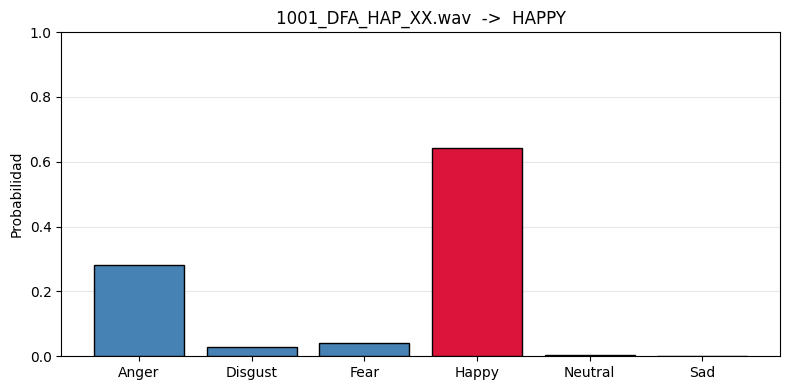

In [50]:
# =====================================================
#            TEST WITH A NEW AUDIO
# =====================================================

def mostrar_prediccion(ruta_wav, reproducir=True):
    """Ejecuta los 5 modelos sobre un .wav y aplica el ensemble final."""
    probs_audio = predecir_audio(ruta_wav)

    print(f'Audio: {os.path.basename(ruta_wav)}\n')
    for m in sorted(probs_audio):
        etq = CLASSES[int(np.argmax(probs_audio[m]))]
        marca = '' if m in MODELOS_FINAL else '   (fuera del ensemble final)'
        print(f'  Modelo {m} -> {NOMBRES[etq].capitalize():8s} '
              f'({probs_audio[m].max():.2f}){marca}')

    P_ens = np.sum([w * probs_audio[m] for m, w in zip(MODELOS_FINAL, PESOS_FINAL)], axis=0)
    print(f'\nWeighted Soft Voting  [{fmt_pesos(MODELOS_FINAL, PESOS_FINAL)}]\n')
    for c, p in sorted(zip(CLASSES, P_ens), key=lambda t: -t[1]):
        print(f'  {NOMBRES[c].capitalize():9s} {p:.4f}  {"#" * int(round(p*40))}')

    final = CLASSES[int(np.argmax(P_ens))]
    print(f'\nFinal prediction: {NOMBRES[final].upper()}')

    fig, ax = plt.subplots(figsize=(8, 4))
    col = ['crimson' if c == final else 'steelblue' for c in CLASSES]
    ax.bar([NOMBRES[c].capitalize() for c in CLASSES], P_ens,
           color=col, edgecolor='black', zorder=3)
    ax.set_ylabel('Probabilidad'); ax.set_ylim(0, 1)
    ax.set_title(f'{os.path.basename(ruta_wav)}  ->  {NOMBRES[final].upper()}')
    ax.grid(axis='y', alpha=0.3, zorder=0)
    plt.tight_layout(); plt.show()

    return (ipd.Audio(ruta_wav) if reproducir else None)


AUDIO_PATH = os.path.join(DATASET_ROOT, '1001_DFA_HAP_XX.wav')   # <-- cambia esto

mostrar_prediccion(AUDIO_PATH)

### 26.1 Grabar un audio nuevo con el microfono

Graba directamente desde el microfono del equipo y lo clasifica con el mismo
sistema. El `.wav` grabado pasa exactamente por la misma ruta que cualquier
audio externo: `predecir_audio()` lo lee con `librosa.load(sr=16000)`, asi que
el remuestreo y el recorte a 3 s se aplican igual.

**Ajuste de nivel.** CREMA-D son grabaciones de estudio con un RMS medio de
~0.029, mientras que un microfono de laptop suele entregar senales bastante mas
debiles. Varias caracteristicas prosodicas del Modelo 1 (`amp_rms`, `amp_pico`,
el contorno de energia) dependen de la amplitud absoluta, asi que una grabacion
floja las sacaria por completo del rango que el modelo vio en entrenamiento. Por
eso la grabacion se reescala al RMS medio del dataset.

> **Sobre la fiabilidad.** Los cinco modelos se entrenaron con audio de estudio,
> actores profesionales y frases fijas en ingles. Una grabacion casera trae ruido
> de fondo, otra respuesta en frecuencia y otra distancia al microfono. La
> prediccion funciona, pero es esperable que acierte menos que sobre Test: es un
> cambio de dominio, no un fallo del sistema.

In [51]:
# ---- Grabacion desde el microfono ----
import sounddevice as sd

# Nivel de referencia: RMS medio de CREMA-D, calculado desde las caracteristicas
RMS_OBJETIVO = float(df_caracteristicas['energia_rms'].mean())
print(f'RMS medio de CREMA-D: {RMS_OBJETIVO:.4f}')


def listar_microfonos():
    """Muestra los dispositivos de entrada disponibles."""
    for i, d in enumerate(sd.query_devices()):
        if d['max_input_channels'] > 0:
            print(f"  [{i}] {d['name'][:55]:57s} sr={int(d['default_samplerate'])}")


def grabar_audio(segundos=DURACION, destino='mi_audio.wav',
                 dispositivo=None, cuenta_atras=3, rms_objetivo=RMS_OBJETIVO):
    """Graba del microfono, ajusta el nivel y guarda un .wav de 16 kHz."""
    info = sd.query_devices(dispositivo, kind='input')
    sr_dev = int(info['default_samplerate'])
    print(f"Microfono: {info['name']}")

    for k in range(cuenta_atras, 0, -1):
        print(f'  {k}...', flush=True)
        time.sleep(1)
    print(f'>>> HABLA AHORA ({segundos:.0f} s)', flush=True)

    grab = sd.rec(int(segundos * sr_dev), samplerate=sr_dev, channels=1,
                  dtype='float32', device=dispositivo)
    sd.wait()
    print('>>> Listo')

    wav = grab.ravel()
    # A 16 kHz, igual que todo el pipeline
    if sr_dev != SR:
        wav = librosa.resample(wav, orig_sr=sr_dev, target_sr=SR)

    rms = float(np.sqrt(np.mean(wav ** 2)))
    if rms < 1e-6:
        print('AVISO: no se capto senal. Revisa que el microfono no este silenciado.')
    else:
        factor = rms_objetivo / rms
        wav = np.clip(wav * factor, -1.0, 1.0)
        print(f'Nivel ajustado: RMS {rms:.4f} -> {rms_objetivo:.4f} (x{factor:.1f})')

    sf.write(destino, wav, SR)
    print(f'Guardado: {destino}  ({len(wav)/SR:.1f} s @ {SR} Hz)')
    return destino


listar_microfonos()

RMS medio de CREMA-D: 0.0279
  [0] Asignador de sonido Microsoft - Input                     sr=44100
  [1] Microphone Array (AMD Audio Dev                           sr=44100
  [4] Controlador primario de captura de sonido                 sr=44100
  [5] Microphone Array (AMD Audio Device)                       sr=44100
  [9] Microphone Array (AMD Audio Device)                       sr=48000
  [10] Microphone Array (AMDAfdInstall Wave Microphone - 0)      sr=48000
  [12] Mezcla estéreo (Realtek HD Audio Stereo input)            sr=48000
  [13] Micrófono (Realtek HD Audio Mic input)                    sr=44100
  [16] Altavoz de PC (Realtek HD Audio 2nd output with HAP)      sr=44100
  [19] Altavoz de PC (Realtek HD Audio output with HAP)          sr=44100


In [52]:
# ---- Grabar y clasificar ----
# Pon GRABAR = True y ejecuta esta celda para grabar con tu microfono.
# Queda en False por defecto para que un "Run All" no se quede esperando.

GRABAR = False
SEGUNDOS = 3.0
DISPOSITIVO = None        # None = microfono por defecto; o el numero de listar_microfonos()

if GRABAR:
    ruta = grabar_audio(segundos=SEGUNDOS, destino='mi_audio.wav',
                        dispositivo=DISPOSITIVO)
    print()
    salida = mostrar_prediccion(ruta)
else:
    print('GRABAR = False. Cambialo a True y vuelve a ejecutar esta celda.')
    print('Consejo: di una frase corta con emocion marcada y pegado al microfono;')
    print('los modelos se entrenaron con actores en estudio, no con voz de fondo.')
    salida = None

salida

GRABAR = False. Cambialo a True y vuelve a ejecutar esta celda.
Consejo: di una frase corta con emocion marcada y pegado al microfono;
los modelos se entrenaron con actores en estudio, no con voz de fondo.


---
## 27. Discusion

### Fortalezas y debilidades de cada modelo

| Modelo | Representacion | Fortaleza | Debilidad |
|---|---|---|---|
| M1 SVC | Prosodia (waveform, 40d) | Captura entonacion y ritmo, que ningun otro mira | Ignora el timbre: confunde emociones con prosodia parecida |
| M2 LogReg | MFCC + Δ + ΔΔ (120d) | El mejor de los tabulares; las derivadas anaden dinamica | Frontera lineal sobre un problema que no lo es |
| M3 Random Forest | MFCC mean + espectrales (27d) | Pocas dimensiones, rapido, no necesita escalado | La menos informativa de las vistas |
| M4 ExtraTrees | Todas las tabulares (127d) | Ve todo lo que hay en la tabla | Al contenerlo todo, replica los errores de M2 y M3 |
| M5 CNN | Log-mel 64x94 | Aprende sus propios filtros sobre el espectrograma | Caja negra, necesita GPU y mas tiempo |

### Las preguntas del enunciado

**¿Que modelos cometen errores similares?** Los que comparten representacion. Las
vistas tabulares (M2, M3, M4) salen todas de `features_cremad.csv`, y `vista_m4`
contiene literalmente a las otras dos, asi que los tres fallan en los mismos
audios.

**¿Cuales son mas complementarios?** Los que parten de representaciones distintas:
el CNN sobre log-mel frente a cualquier modelo tabular, y la prosodia frente a
todo lo cepstral. La grafica de la seccion 22 lo muestra: menos correlacion se
traduce en mas audios donde uno salva al otro.

**¿Un modelo mas debil puede corregir a uno fuerte?** Si, y es justo lo que
sostiene al ensemble. Un modelo con Macro F1 mas bajo pero errores distintos
aporta mas que uno fuerte que repite los errores del resto.

**¿Representaciones distintas producen errores distintos?** Esa es la conclusion
central de todo el trabajo, y aqui se puede medir: al cambiar el Modelo 1 de MFCC
a prosodia su rendimiento individual bajo un poco, pero su correlacion con el
resto cayo de forma clara. Es el intercambio que hace util a un ensemble.

**¿La diversidad explica la mejora?** Comparando las 26 combinaciones se ve que
las que ganan no son las que juntan los modelos mas fuertes, sino las que
combinan **representaciones distintas**.

---
## 28. Conclusiones

1. **La representacion importa mas que el algoritmo.** Cambiar de SVC a Logistic
   Regression o a Random Forest sobre las mismas caracteristicas mueve poco el
   resultado; cambiar de MFCC a log-mel lo mueve mucho.

2. **Un ensemble no mejora por sumar modelos.** Si estan correlacionados, los
   modelos debiles ganan la votacion al fuerte y el promedio empeora. Por eso el
   Uniform Soft Voting rinde por debajo del mejor modelo individual.

3. **Los pesos tienen que salir de Validation.** El Weighted Soft Voting recupera
   lo que el uniforme pierde justamente porque aprende a cuanto ignorar a los
   modelos que estorban.

4. **Mas modelos no es mejor.** El analisis de las 26 combinaciones y el
   Leave-One-Model-Out muestran que una seleccion de menos modelos iguala o supera
   a los cinco juntos.

5. **Metodologia.** Particion speaker-disjoint verificada, Test abierto una sola
   vez al final, modelos entrenados una sola vez y todos los analisis hechos sobre
   probabilidades guardadas, sin reentrenar.